# Inspeção, EDA Profunda e Pré-Processamento do Dataset

**Feito por: Bernardo e Hugo**

## Nota Técnica: Estratégia de Amostragem

O dataset Avazu CTR Prediction contém **40.428.967 registos**, o que inviabiliza o carregamento direto com `pd.read_csv()` (esgota a RAM do Kaggle) e impossibilita o upload para o GitHub.

Por sugestão da professora, foi adotada uma estratégia de analisar apenas uma **amostra aleatória de 5.000.000 registos** (`random_state=42`), garantindo:
- **Reprodutibilidade total**: a mesma semente produz sempre a mesma amostra
- **Representatividade estatística**: amostragem aleatória simples sem viés
- **Compatibilidade com o Kaggle**: ~2 GB em memória, dentro dos limites

Todas as células seguintes operam sobre este `df` — **não recarregar o ficheiro**.

In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/hugogrou/previso-de-cliques/train.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/sampleSubmission/sampleSubmission.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/test/test.csv
/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv


## 1. Carregamento da Amostra (5 Milhões de Registos)

A amostra é seleccionada aleatoriamente com semente fixa (`random_state=42`).
Todas as células seguintes utilizam este mesmo `df` — **não recarregar o ficheiro**.

In [2]:
FILE_PATH     = "/kaggle/input/datasets/madhu41289/avazu-ctr-prediction-exp/train/train.csv"
TOTAL_ROWS    = 40_428_967   # total de linhas no ficheiro original (sem header)
SAMPLE_SIZE   = 5_000_000   # amostra sugerida pela professora
RANDOM_STATE  = 42           # semente fixa — não alterar

np.random.seed(RANDOM_STATE)
keep_indices = set(np.random.choice(TOTAL_ROWS, size=SAMPLE_SIZE, replace=False))

print(f"A carregar {SAMPLE_SIZE:,} registos aleatórios de {TOTAL_ROWS:,} ({SAMPLE_SIZE/TOTAL_ROWS*100:.1f}%)...")

df = pd.read_csv(
    FILE_PATH,
    skiprows=lambda i: i > 0 and (i - 1) not in keep_indices
)
df = df.reset_index(drop=True)

print(f"   Dimensão: {df.shape[0]:,} registos × {df.shape[1]} colunas")

A carregar 5,000,000 registos aleatórios de 40,428,967 (12.4%)...
   Dimensão: 5,000,000 registos × 24 colunas


## 2. Inspeção da Amostra Bruta

Análise inicial completa: dimensões, primeiras linhas, tipos, nulos, estatísticas numéricas e categóricas.

In [3]:
print("DIMENSÃO")
print(f"  {df.shape[0]:,} registos × {df.shape[1]} colunas")

print("\nPRIMEIRAS 5 LINHAS")
display(df.head())

print("\nTIPOS DE DADOS")
display(df.dtypes.to_frame("Tipo"))

print("\nVALORES NULOS")
null_counts = df.isnull().sum()
display(null_counts.to_frame("Nulos"))
print(f"Total de valores nulos: {int(null_counts.sum())}")

print("\nESTATÍSTICAS NUMÉRICAS")
display(df.describe())

print("\nESTATÍSTICAS CATEGÓRICAS")
cat_cols = df.select_dtypes(include="object").columns.tolist()
if cat_cols:
    cat_summary = {}
    for col in cat_cols:
        vc = df[col].value_counts()
        cat_summary[col] = {
            "count":  df[col].notna().sum(),
            "unique": df[col].nunique(),
            "top":    vc.index[0],
            "freq":   int(vc.iloc[0])
        }
    display(pd.DataFrame(cat_summary).T)
else:
    print("  Sem colunas categóricas.")

DIMENSÃO
  5,000,000 registos × 24 colunas

PRIMEIRAS 5 LINHAS


,id,click,hour,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,...,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
0,10000371904215119486,0,14102100,1005,0,1fbe01fe,f3845767,28905ebd,ecad2386,7801e8d9,...,1,0,15704,320,50,1722,0,35,100084,79
1,10001264480619467364,0,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21689,320,50,2496,3,167,100191,23
2,10004670021948955159,0,14102100,1005,0,543a539e,c7ca3108,3e814130,ecad2386,7801e8d9,...,1,0,20366,320,50,2333,0,39,-1,157
3,10007847530896919634,1,14102100,1002,0,84c7ba46,c4e18dd6,50e219e0,ecad2386,7801e8d9,...,0,0,21661,320,50,2446,3,171,100228,156
4,10010966574628106108,1,14102100,1005,0,85f751fd,c4e18dd6,50e219e0,0acbeaa3,45a51db4,...,1,0,20596,320,50,2161,0,35,100034,157



TIPOS DE DADOS


,Tipo
id,uint64
click,int64
hour,int64
C1,int64
banner_pos,int64
site_id,object
site_domain,object
site_category,object
app_id,object
app_domain,object



VALORES NULOS


,Nulos
id,0
click,0
hour,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0


Total de valores nulos: 0

ESTATÍSTICAS NUMÉRICAS


,id,click,hour,C1,banner_pos,device_type,device_conn_type,C14,C15,C16,C17,C18,C19,C20,C21
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,9.223480e+18,1.697188e-01,1.410256e+07,1.004968e+03,2.881012e-01,1.015408e+00,3.300478e-01,1.884259e+04,3.188800e+02,6.005896e+01,2.112686e+03,1.432106e+00,2.272310e+02,5.317426e+04,8.340489e+01
std,5.325474e+18,3.753856e-01,2.967201e+02,1.095621e+00,5.057768e-01,5.279241e-01,8.530219e-01,4.958047e+03,2.123737e+01,4.722027e+01,6.092178e+02,1.326446e+00,3.510607e+02,4.995947e+04,7.029536e+01
min,5.211594e+11,0.000000e+00,1.410210e+07,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,1.120000e+02,0.000000e+00,3.300000e+01,-1.000000e+00,1.000000e+00
25%,4.609911e+18,0.000000e+00,1.410230e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,1.863000e+03,0.000000e+00,3.500000e+01,-1.000000e+00,2.300000e+01
50%,9.226424e+18,0.000000e+00,1.410260e+07,1.005000e+03,0.000000e+00,1.000000e+00,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.323000e+03,2.000000e+00,3.900000e+01,1.000480e+05,6.100000e+01
75%,1.383619e+19,0.000000e+00,1.410281e+07,1.005000e+03,1.000000e+00,1.000000e+00,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,2.526000e+03,3.000000e+00,1.710000e+02,1.000880e+05,1.010000e+02
max,1.844674e+19,1.000000e+00,1.410302e+07,1.012000e+03,7.000000e+00,5.000000e+00,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,2.758000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02



ESTATÍSTICAS CATEGÓRICAS


,count,unique,top,freq
site_id,5000000,3552,85f751fd,1804850
site_domain,5000000,4523,c4e18dd6,1871216
site_category,5000000,22,50e219e0,2044793
app_id,5000000,5239,ecad2386,3195150
app_domain,5000000,340,7801e8d9,3369186
app_category,5000000,31,07d7df22,3236597
device_id,5000000,598510,a99f214a,4126150
device_ip,5000000,1904861,6b9769f2,26025
device_model,5000000,6509,8a4875bd,304562


Esta célula executa uma auditoria completa ao dataset, começando por quantificar a sua dimensão e exibir uma amostra visual das primeiras cinco linhas para validar a estrutura. De seguida, mapeia os tipos de dados de cada coluna e identifica a presença de valores nulos, métricas essenciais para planear a futura limpeza e tratamento de erros. O código calcula ainda estatísticas descritivas para as variáveis numéricas, permitindo detetar anomalias ou distribuições enviesadas logo na fase inicial. Para as variáveis categóricas, o script resume a diversidade de classes e identifica os padrões mais frequentes, garantindo que os dados qualitativos são representativos. Em suma, esta rotina transforma dados brutos num diagnóstico técnico que valida a viabilidade de todo o projeto de Ciência de Dados.


Feito por: Bernardo e Hugo

In [4]:
import pandas as pd

# 1. Definição do perfil de dados esperado (Dicionário de tipos alvo)
tipos_alvo = {
    'id': 'float64', 'click': 'int64', 'hour': 'int64', 'C1': 'int64',
    'banner_pos': 'int64', 'site_id': 'object', 'site_domain': 'object',
    'site_category': 'object', 'app_id': 'object', 'app_domain': 'object',
    'app_category': 'object', 'device_id': 'object', 'device_ip': 'object',
    'device_model': 'object', 'device_type': 'int64', 'device_conn_type': 'int64',
    'C14': 'int64', 'C15': 'int64', 'C16': 'int64', 'C17': 'int64',
    'C18': 'int64', 'C19': 'int64', 'C20': 'int64', 'C21': 'int64'
}

# 2. Verificação de Conformidade dos Tipos de Dados
print(f"{'Variável':<22} {'Tipo Detetado':<15} {'Tipo Alvo':<15} {'Estado'}")
print('-' * 75)

for coluna, alvo in tipos_alvo.items():
    if coluna in df.columns:
        detetado = str(df[coluna].dtype)
        estado = 'Correto' if detetado == alvo else 'A corrigir'
        print(f"{coluna:<22} {detetado:<15} {alvo:<15} {estado}")

# 3. Análise de Valores em Falta (identificados por -1 no dataset Avazu)
colunas_anonimas = [f'C{i}' for i in range(14, 22)]
print("\nDADOS EM FALTA (Marcador -1):")
print(f"{'Atributo':<12} {'Frequência':>15} {'Percentagem':>12}")
print('-' * 45)

for col in colunas_anonimas:
    if col in df.columns:
        contagem_neg = (df[col] == -1).sum()
        percentagem = (contagem_neg / len(df)) * 100
        print(f"{col:<12} {contagem_neg:>15,} {percentagem:>11.2f}%")

# 4. Verificação de Observações Repetidas (Requisito da Milestone 1)
print("\nVERIFICAÇÃO DE REGISTOS DUPLICADOS:")
total_duplicados = df.duplicated().sum()
print(f"Total de linhas repetidas encontradas: {total_duplicados}")

Variável               Tipo Detetado   Tipo Alvo       Estado
---------------------------------------------------------------------------
id                     uint64          float64         A corrigir
click                  int64           int64           Correto
hour                   int64           int64           Correto
C1                     int64           int64           Correto
banner_pos             int64           int64           Correto
site_id                object          object          Correto
site_domain            object          object          Correto
site_category          object          object          Correto
app_id                 object          object          Correto
app_domain             object          object          Correto
app_category           object          object          Correto
device_id              object          object          Correto
device_ip              object          object          Correto
device_model           object          o

Esta célula verifica se todas as colunas do dataset apresentam o formato técnico adequado, comparando o tipo de dados atual com o objetivo definido para o projeto. Através desta inspeção, o código assinala como "Correto" ou "A corrigir" cada variável, facilitando a identificação imediata de erros de importação. Adicionalmente, é realizada uma contagem dos valores "-1" nas colunas anónimas, que funcionam como indicadores de dados em falta. O resultado final apresenta a percentagem de omissões em cada campo, permitindo avaliar a qualidade da informação disponível. Esta análise é fundamental para garantir que a base de dados é fiável antes de avançar para a fase de modelação.

Feito por: Bernardo e Hugo

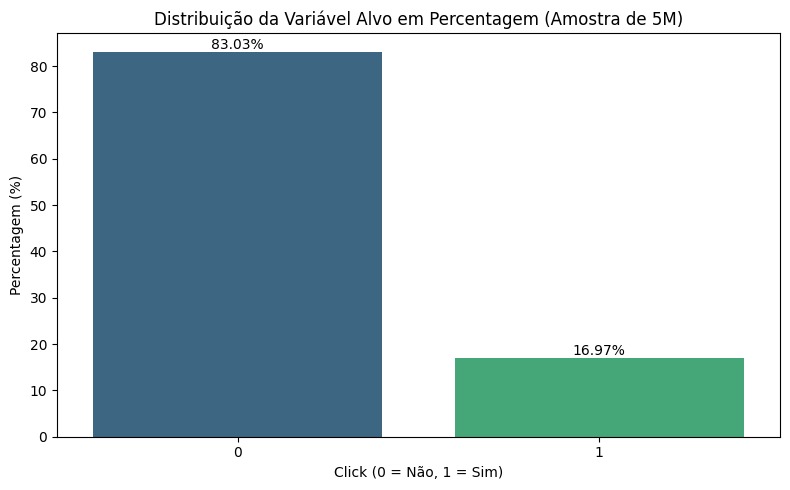

Cliques  (1): 848,594 (16.97%)
Não-cliques (0): 4,151,406 (83.03%)
Rácio desbalanceamento: 1:4


In [5]:
target_counts = df['click'].value_counts()
total = target_counts.sum()
target_pct = (target_counts / total) * 100

plt.figure(figsize=(8, 5))
ax = sns.barplot(x=target_pct.index, y=target_pct.values,
                 hue=target_pct.index, palette='viridis', legend=False)
plt.title('Distribuição da Variável Alvo em Percentagem (Amostra de 5M)')
plt.xlabel('Click (0 = Não, 1 = Sim)')
plt.ylabel('Percentagem (%)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%',
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points')
plt.tight_layout()
plt.show()

print(f"Cliques  (1): {int(target_counts[1]):,} ({target_pct[1]:.2f}%)")
print(f"Não-cliques (0): {int(target_counts[0]):,} ({target_pct[0]:.2f}%)")
print(f"Rácio desbalanceamento: 1:{target_counts[0]//target_counts[1]:.0f}")

Nesta secção, analisamos a distribuição da variável click. Esta etapa é crucial para o entendimento do problema, pois permite quantificar o desequilíbrio entre as classes. Como observado, o rácio de desequilíbrio é elevado, o que poderá condicionar a escolha dos algoritmos e das métricas de avaliação, priorizando o AUC-ROC em detrimento da exatidão (Accuracy).

Feito por: Bernardo e Hugo

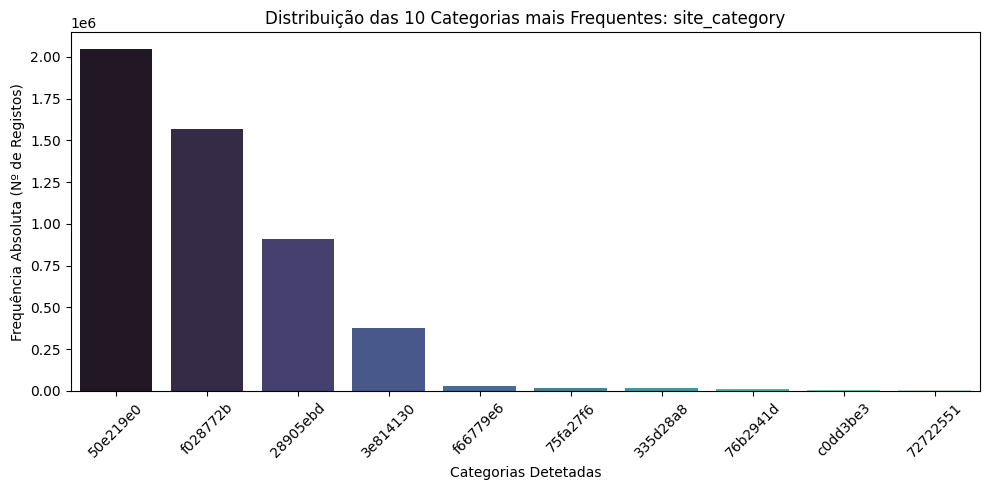

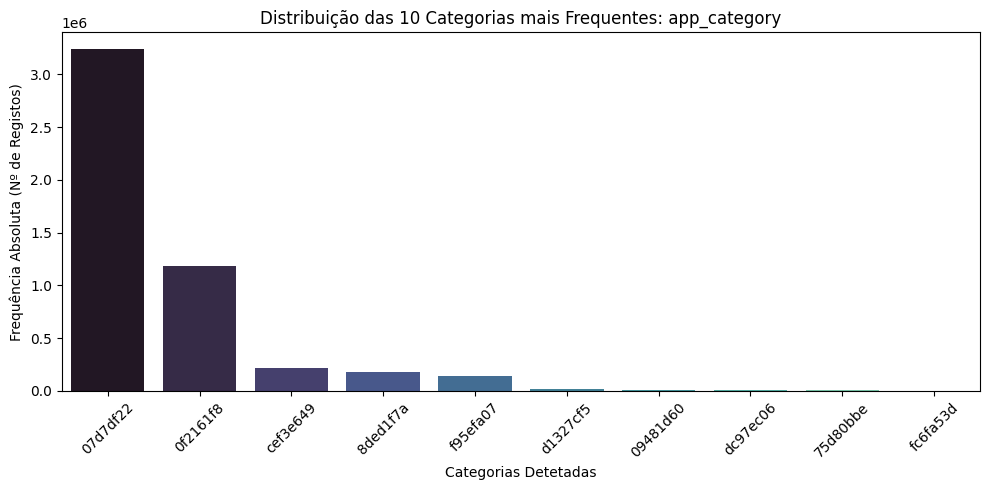

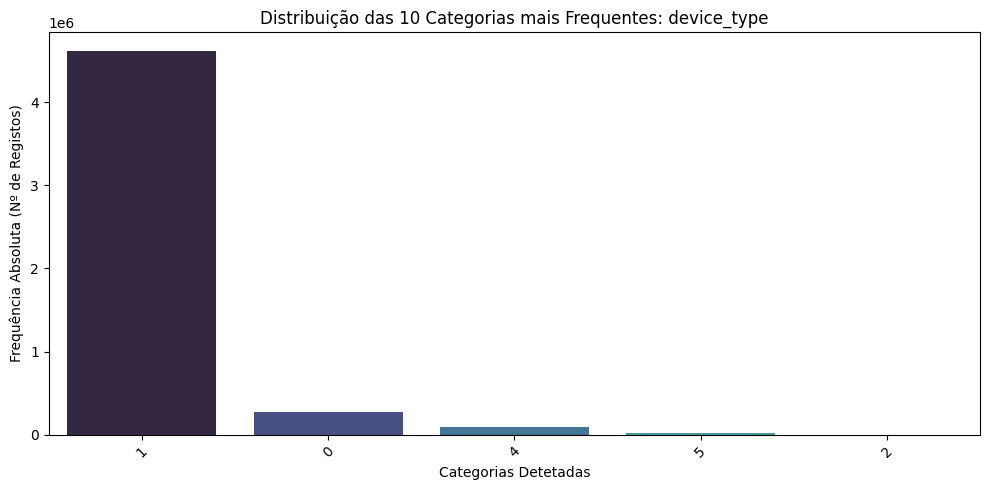

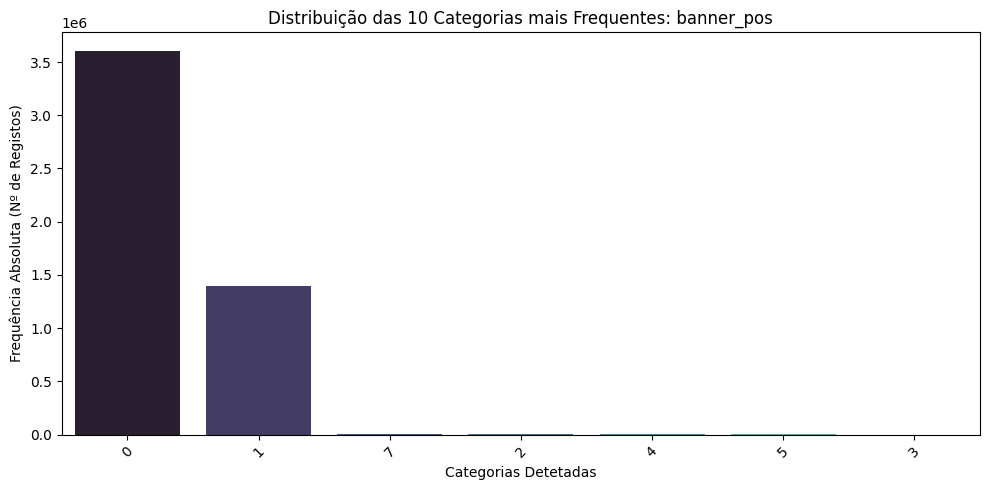

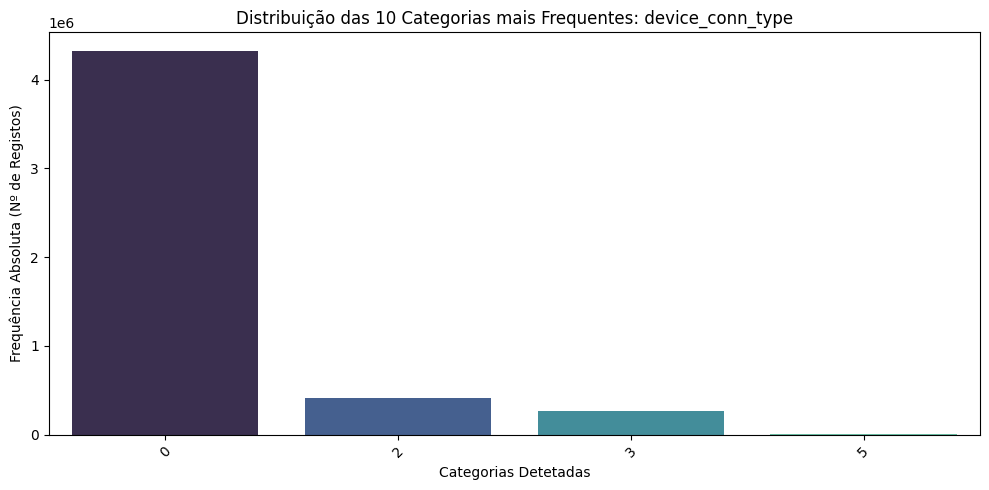

In [6]:
# Lista de colunas para análise de frequência
colunas_alvo = ['site_category', 'app_category', 'device_type', 'banner_pos', 'device_conn_type']

for col in colunas_alvo:
    # Contagem de frequências convertendo para texto para garantir a inclusão do -1
    contagem = df[col].astype(str).value_counts()
    
    # Tratamento técnico do marcador de dados em falta (-1)
    if '-1' in contagem.index:
        contagem = contagem.rename({'-1': 'Dados Omissos'})
    
    top_10 = contagem.head(10)

    plt.figure(figsize=(10, 5))
    ax = sns.barplot(x=top_10.index, y=top_10.values,
                     hue=top_10.index, palette='mako', legend=False)
    
    plt.title(f'Distribuição das 10 Categorias mais Frequentes: {col}')
    plt.xlabel('Categorias Detetadas')
    plt.ylabel('Frequência Absoluta (Nº de Registos)')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Esta visualização permite identificar os segmentos mais representativos no dataset. Por exemplo, a predominância de certas categorias em site_category ou app_category indica onde os anúncios são mais exibidos.

Ponto Crítico Detetado: A presença de categorias "Desconhecidas" (antigos valores -1) em variáveis como device_conn_type revela que uma parte da amostra não possui dados de conectividade, o que será um fator a considerar na fase de limpez.

Feito por: Bernardo e Hugo

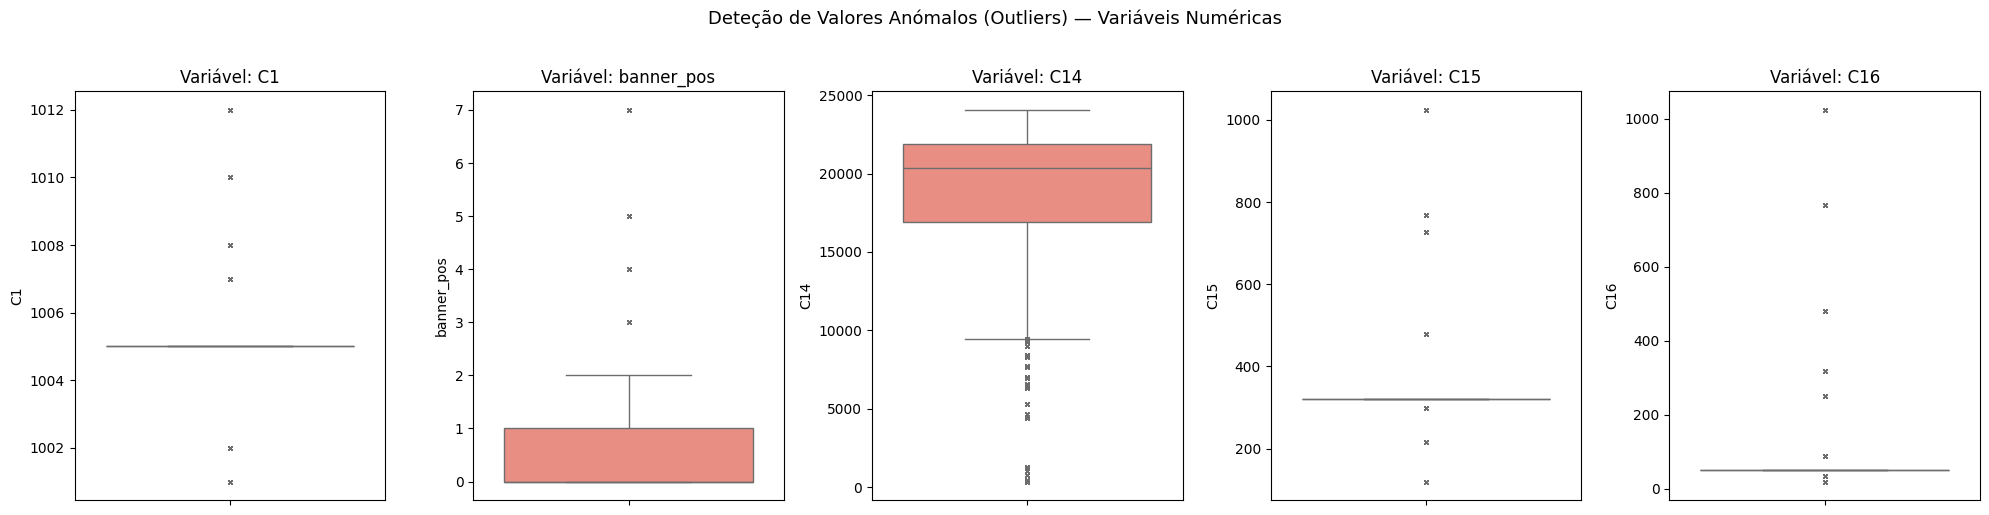

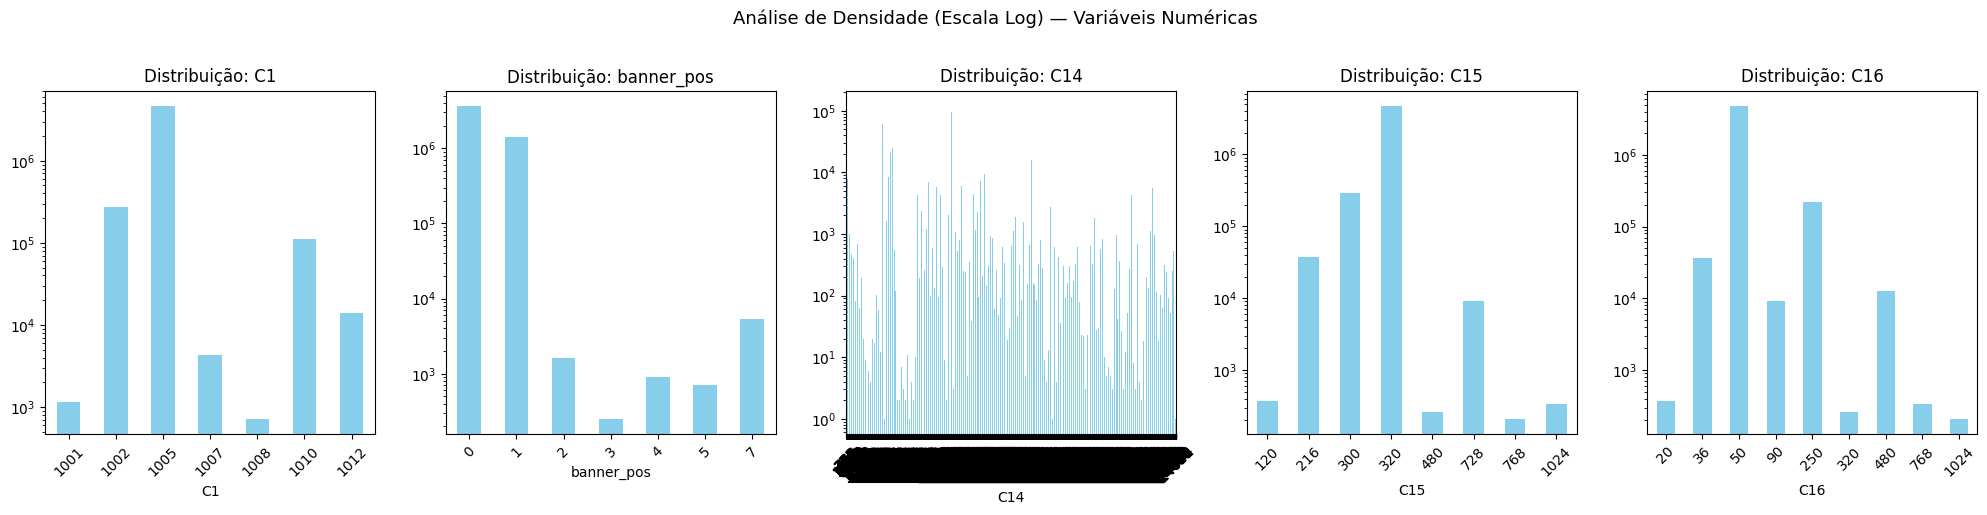

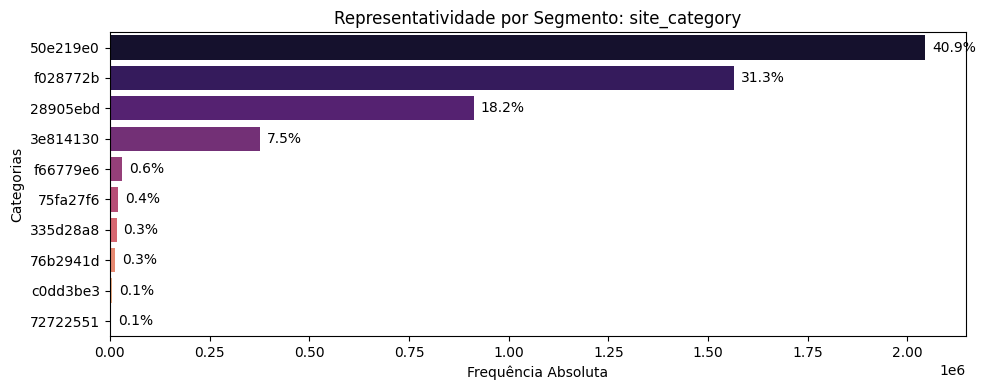

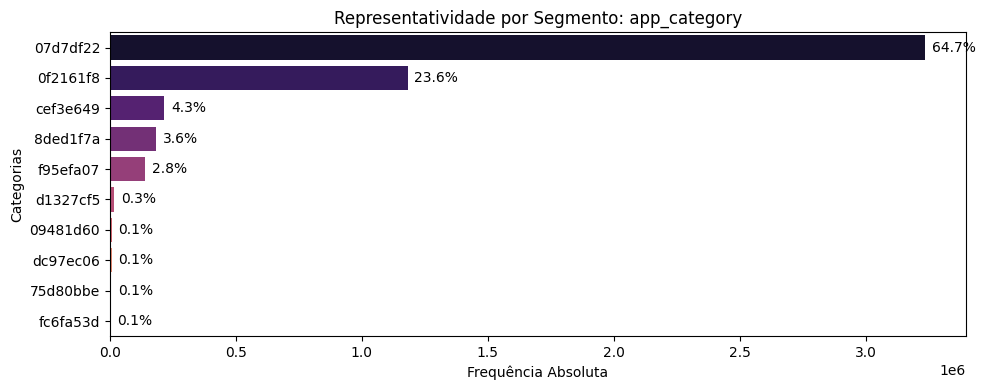

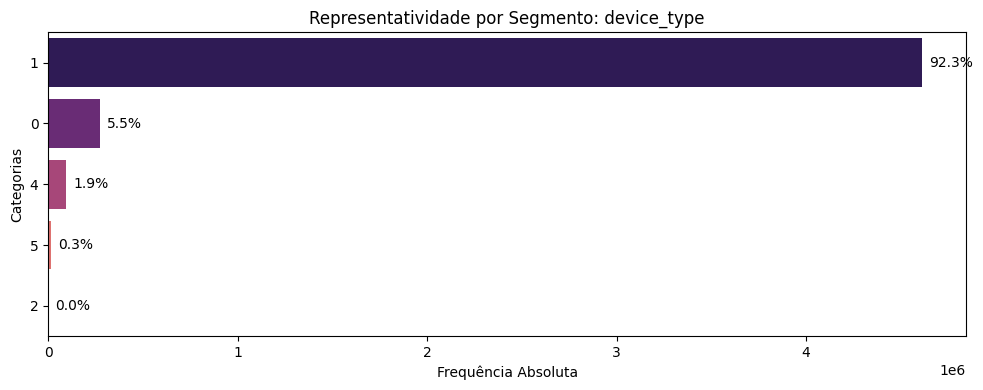

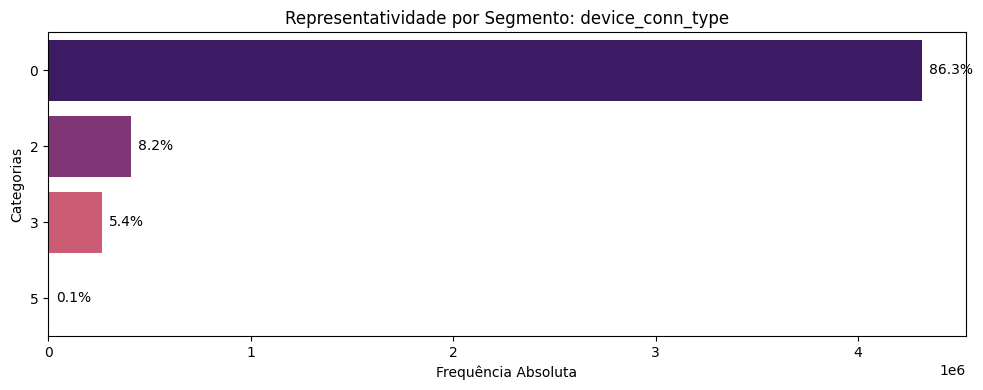

In [7]:
# 1. Identificação de Anomalias (Outliers)
plt.figure(figsize=(20, 5))
cols_box = ['C1', 'banner_pos', 'C14', 'C15', 'C16']
for i, col in enumerate(cols_box):
    plt.subplot(1, 5, i + 1)
    sns.boxplot(y=df[col], color='salmon',
                flierprops={'marker': 'x', 'markerfacecolor': 'red', 'markersize': 3})
    plt.title(f'Variável: {col}')

plt.suptitle('Deteção de Valores Anómalos (Outliers) — Variáveis Numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 2. Distribuição de Frequências (Escala Logarítmica)
plt.figure(figsize=(20, 5))
for i, col in enumerate(cols_box):
    plt.subplot(1, 5, i + 1)
    # Ordenamos pelo índice para perceber a dispersão dos valores numéricos
    df[col].value_counts().sort_index().plot(kind='bar', color='skyblue', ax=plt.gca())
    plt.yscale('log')
    plt.title(f'Distribuição: {col}')
    plt.xticks(rotation=45)

plt.suptitle('Análise de Densidade (Escala Log) — Variáveis Numéricas', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# 3. Relevância das Categorias (Percentagem do Total)
cols_cat_num = ['site_category', 'app_category', 'device_type', 'device_conn_type']
for col in cols_cat_num:
    plt.figure(figsize=(10, 4))
    # Analisamos os 10 atributos mais frequentes
    top_10 = df[col].astype(str).value_counts().head(10)
    ax = sns.barplot(x=top_10.values, y=top_10.index,
                     hue=top_10.index, palette='magma', legend=False)
    
    # Adicionamos a percentagem relativa ao dataset total
    for p in ax.patches:
        percentagem = '{:.1f}%'.format(100 * p.get_width() / df[col].count())
        ax.annotate(percentagem, (p.get_width(), p.get_y() + p.get_height() / 2),
                    xytext=(5, 0), textcoords='offset points', va='center')
    
    plt.title(f'Representatividade por Segmento: {col}')
    plt.xlabel('Frequência Absoluta')
    plt.ylabel('Categorias')
    plt.tight_layout()
    plt.show()

Este código permite ver a distribuição dos dados, utilizando *boxplots* para identificar valores anómalos e histogramas em escala logarítmica para analisar a dispersão de variáveis numéricas. Em suma, estas visualizações fundamentam as decisões de limpeza e engenharia de atributos que serão executadas nas fases seguintes do projeto.

Feito por: Bernardo e Hugo

In [8]:
def calcular_outliers_iqr(df, cols):
    resultados = []
    print(f"{'Coluna':<20} | {'Outliers':>12} | {'% Total':>8} | {'Limite Inf':>12} | {'Limite Sup':>12}")
    print('-' * 72)
    for col in cols:
        if col not in df.columns:
            continue
        s = df[col].dropna()
        q1, q3 = s.quantile(0.25), s.quantile(0.75)
        iqr = q3 - q1
        li, ls = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((s < li) | (s > ls)).sum()
        pct = n_out / len(s) * 100
        resultados.append({'Coluna': col, 'Outliers': int(n_out),
                            '% Total': round(pct, 2),
                            'Limite Inf': round(li, 2), 'Limite Sup': round(ls, 2)})
        print(f"{col:<20} | {n_out:>12,} | {pct:>7.2f}% | {li:>12.2f} | {ls:>12.2f}")
    return pd.DataFrame(resultados)

cols_num_iqr = ['C1', 'banner_pos', 'C14', 'C15', 'C16', 'C17',
                'C18', 'C19', 'C20', 'C21', 'device_type', 'device_conn_type']
df_outliers = calcular_outliers_iqr(df, cols_num_iqr)
print("\nTabela resumo:")
display(df_outliers)

Coluna               |     Outliers |  % Total |   Limite Inf |   Limite Sup
------------------------------------------------------------------------
C1                   |      407,113 |    8.14% |      1005.00 |      1005.00
banner_pos           |        7,194 |    0.14% |        -1.50 |         2.50
C14                  |      414,103 |    8.28% |      9459.00 |     29355.00
C15                  |      335,555 |    6.71% |       320.00 |       320.00
C16                  |      282,461 |    5.65% |        50.00 |        50.00
C17                  |      423,361 |    8.47% |       868.50 |      3520.50
C18                  |            0 |    0.00% |        -4.50 |         7.50
C19                  |      900,776 |   18.02% |      -169.00 |       375.00
C20                  |            0 |    0.00% |   -150134.50 |    250221.50
C21                  |      713,315 |   14.27% |       -94.00 |       218.00
device_type          |      386,796 |    7.74% |         1.00 |         1.00
dev

,Coluna,Outliers,% Total,Limite Inf,Limite Sup
0,C1,407113,8.14,1005.0,1005.0
1,banner_pos,7194,0.14,-1.5,2.5
2,C14,414103,8.28,9459.0,29355.0
3,C15,335555,6.71,320.0,320.0
4,C16,282461,5.65,50.0,50.0
5,C17,423361,8.47,868.5,3520.5
6,C18,0,0.00,-4.5,7.5
7,C19,900776,18.02,-169.0,375.0
8,C20,0,0.00,-150134.5,250221.5
9,C21,713315,14.27,-94.0,218.0


Este código utiliza o método do Intervalo Interquartil (IQR) para identificar matematicamente valores anómalos nas variáveis numéricas. Estes resultados são fundamentais para decidir, na fase seguinte, quais os dados que devem ser corrigidos ou removidos.

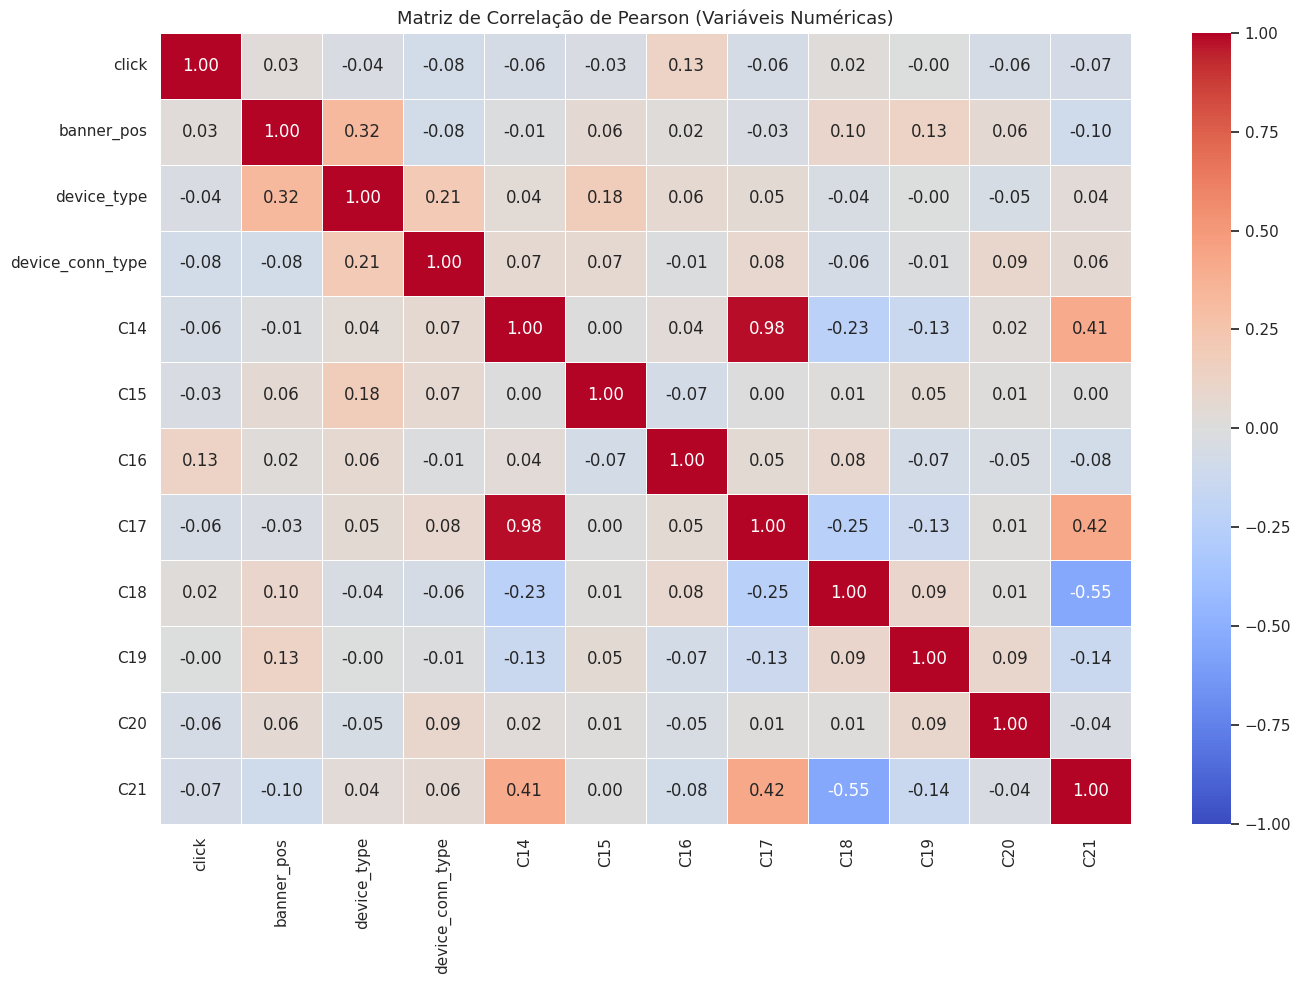

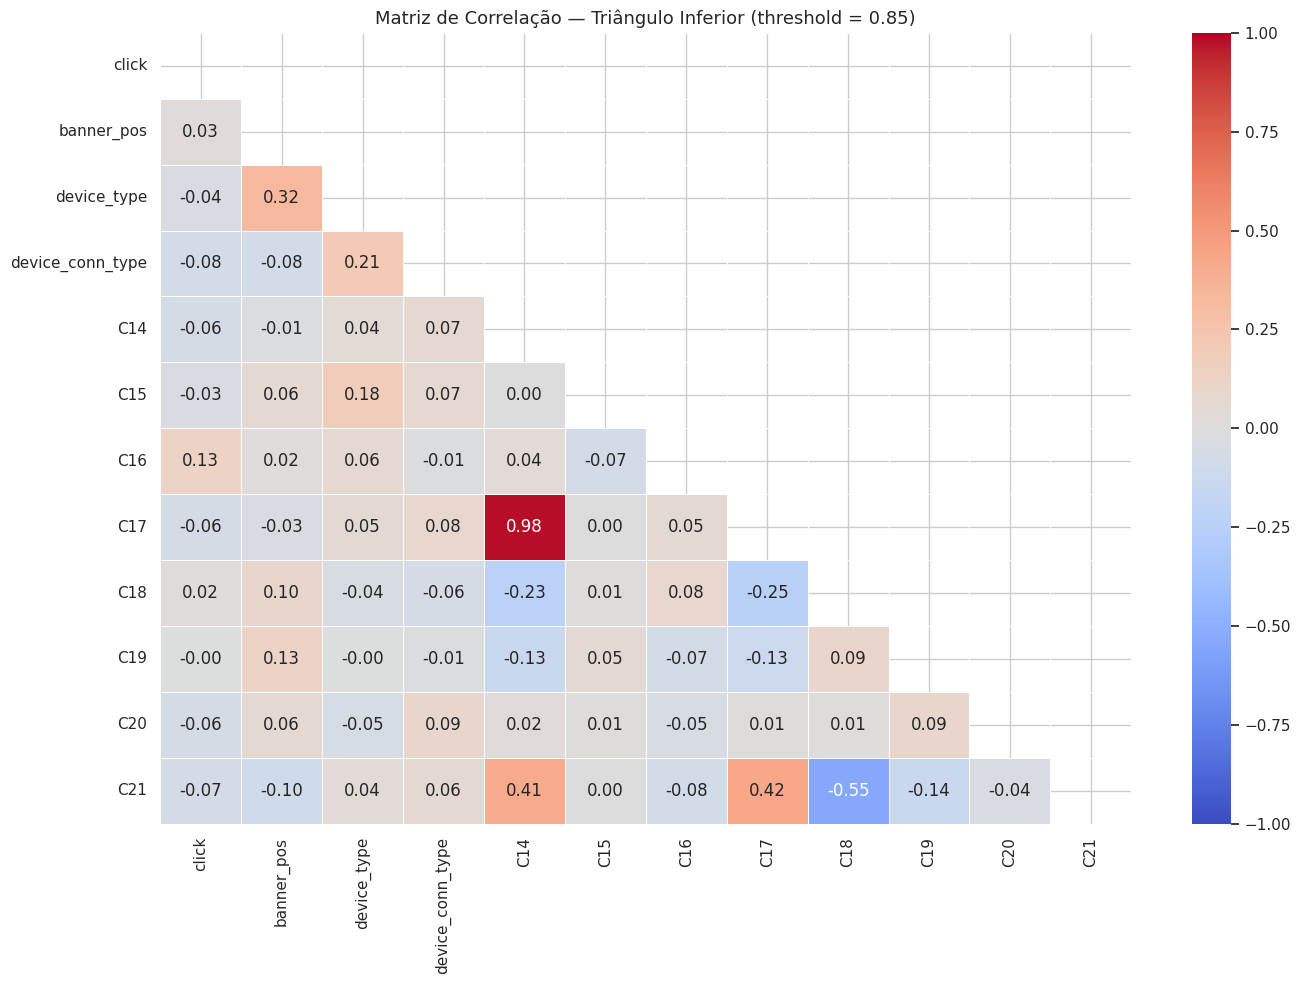

Correlações com a variável alvo ('click'):
  C16                      : +0.1303
  device_conn_type         : -0.0832
  C21                      : -0.0698
  C14                      : -0.0608
  C20                      : -0.0580
  C17                      : -0.0561
  device_type              : -0.0374
  C15                      : -0.0325
  banner_pos               : +0.0263
  C18                      : +0.0216
  C19                      : -0.0038

Pares com |correlação| > 0.85 (multicolinearidade):
  C14  ↔  C17  →  r = 0.9769


,Var A,Var B,r
0,C14,C17,0.9769


In [9]:
sns.set_theme(style='whitegrid')

cols_to_correlate = ['click', 'banner_pos', 'device_type', 'device_conn_type',
                     'C14', 'C15', 'C16', 'C17', 'C18', 'C19', 'C20', 'C21']

corr_df = df[cols_to_correlate].corr()

# Heatmap completo 
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação de Pearson (Variáveis Numéricas)', fontsize=13)
plt.tight_layout()
plt.show()

# Heatmap triangular 
mask = np.triu(np.ones_like(corr_df.values, dtype=bool))
plt.figure(figsize=(14, 10))
sns.heatmap(corr_df, mask=mask, annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.4, vmin=-1, vmax=1, center=0)
plt.title('Matriz de Correlação — Triângulo Inferior (threshold = 0.85)', fontsize=13)
plt.tight_layout()
plt.show()

#  Correlações com a variável alvo 
print("Correlações com a variável alvo ('click'):")
corr_alvo = corr_df['click'].drop('click').sort_values(key=abs, ascending=False)
for col, val in corr_alvo.items():
    print(f"  {col:<25}: {val:+.4f}")

# Pares com multicolinearidade 
THRESHOLD = 0.85
print(f"\nPares com |correlação| > {THRESHOLD} (multicolinearidade):")
pares = []
cols_list = list(corr_df.columns)
for i in range(len(cols_list)):
    for j in range(i+1, len(cols_list)):
        r = corr_df.iloc[i, j]
        if abs(r) > THRESHOLD:
            pares.append({'Var A': cols_list[i], 'Var B': cols_list[j], 'r': round(r, 4)})
            print(f"  {cols_list[i]}  ↔  {cols_list[j]}  →  r = {r:.4f}")
if not pares:
    print("  Nenhum par acima do threshold.")
else:
    display(pd.DataFrame(pares).sort_values('r', key=abs, ascending=False))

Este código gera uma matriz de correlação de Pearson para identificar relações lineares entre as variáveis numéricas e a variável alvo. Podemos observar pares com elevada multicolinearidade, permitindo antecipar a remoção de dados redundantes. Esta análise é vital para garantir a eficiência e a interpretabilidade dos modelos preditivos que serão desenvolvidos.

Feito por: Bernardo e Hugo

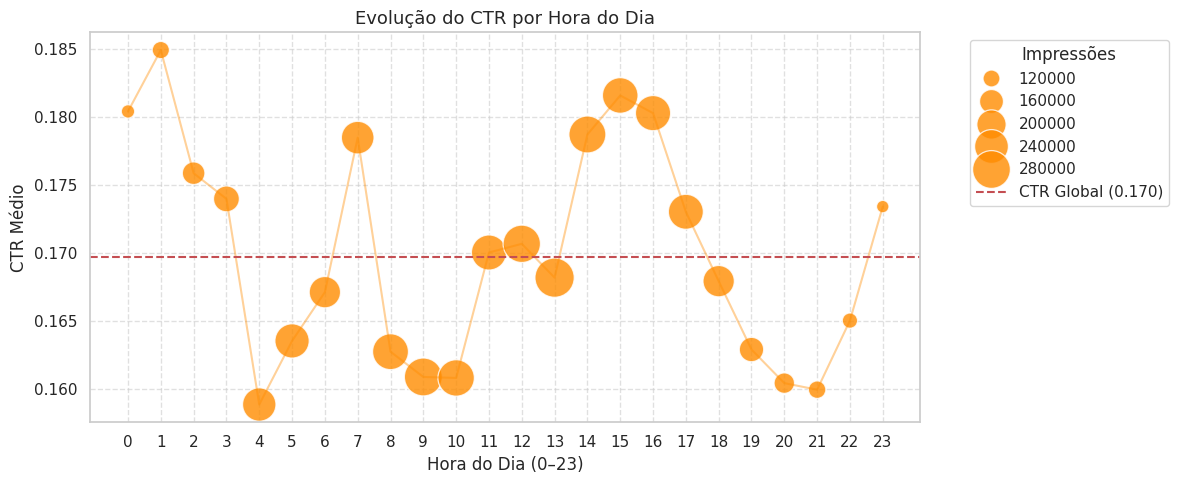

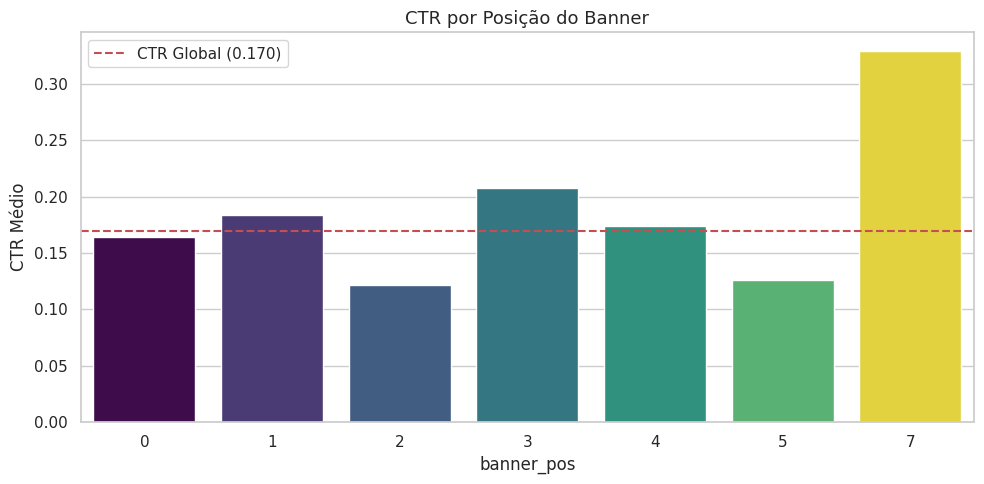

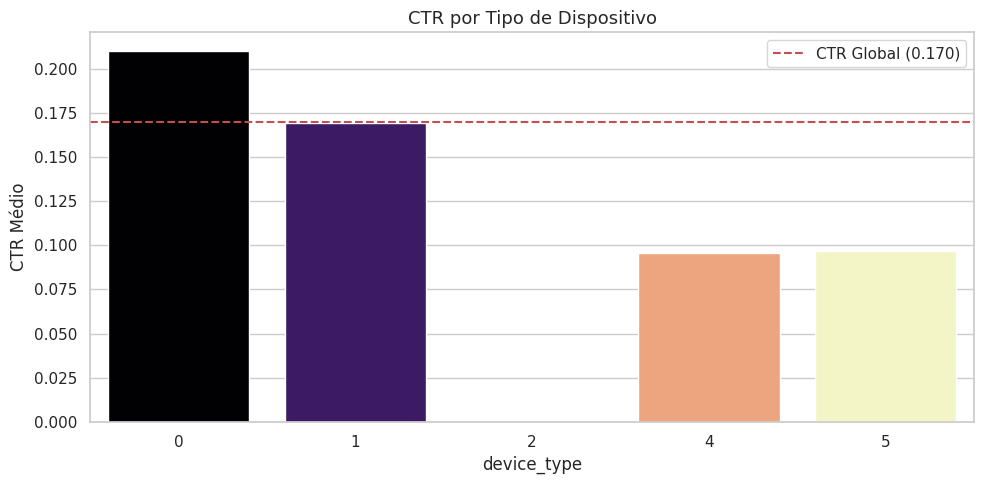

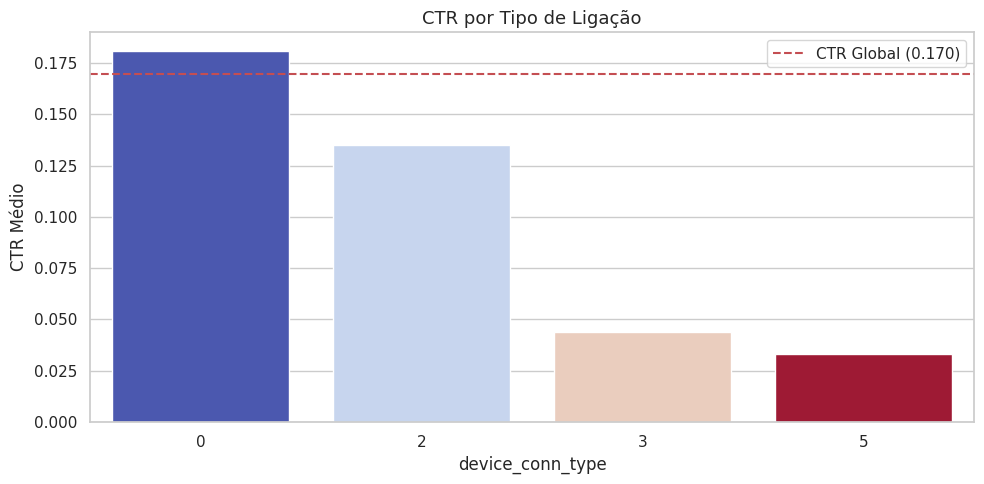

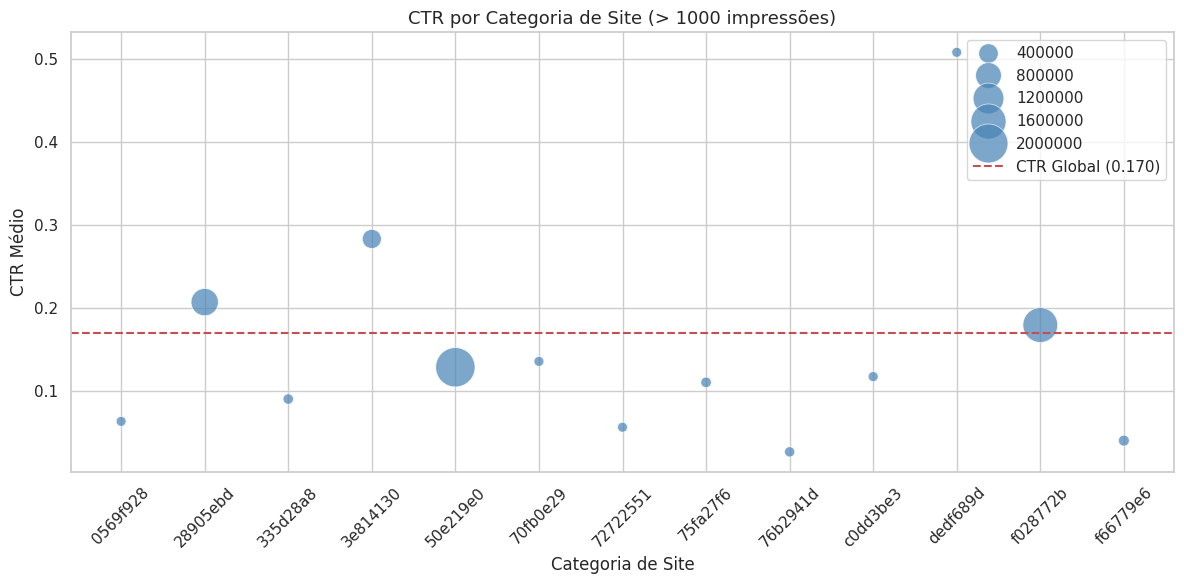

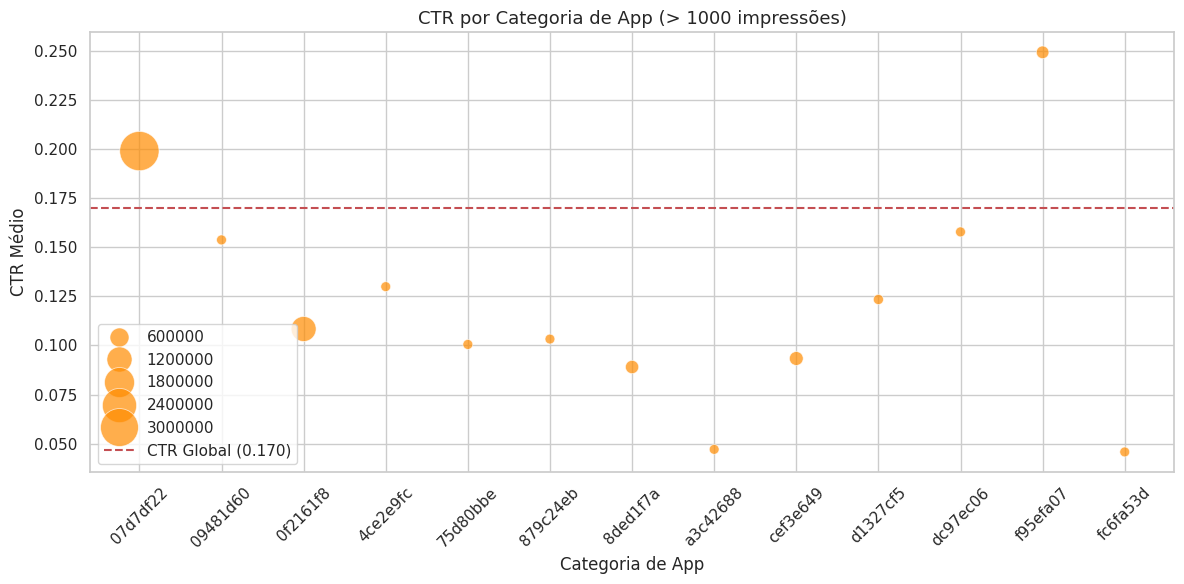

In [10]:
# Preparar coluna hora_do_dia temporária 
df_eda = df.copy()
df_eda['hora_do_dia'] = df_eda['hour'] % 100

global_ctr = df_eda['click'].mean()

def plot_ctr_bar(stats_df, x_col, title, palette='viridis'):
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=stats_df, x=x_col, y='CTR',
                     hue=x_col, palette=palette, legend=False)
    plt.axhline(global_ctr, color='r', linestyle='--',
                label=f'CTR Global ({global_ctr:.3f})')
    plt.title(title, fontsize=13)
    plt.xlabel(x_col)
    plt.ylabel('CTR Médio')
    plt.legend()
    plt.tight_layout()
    plt.show()

# CTR por Hora do Dia 
df_hour = df_eda.groupby('hora_do_dia')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_hour['CTR'] = df_hour['clicks'] / df_hour['impressions']
df_hour.sort_values('hora_do_dia', inplace=True)

plt.figure(figsize=(12, 5))
sns.scatterplot(data=df_hour, x='hora_do_dia', y='CTR',
                size='impressions', sizes=(80, 800), color='darkorange', alpha=0.8)
sns.lineplot(data=df_hour, x='hora_do_dia', y='CTR', color='darkorange', alpha=0.4)
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('Evolução do CTR por Hora do Dia', fontsize=13)
plt.xlabel('Hora do Dia (0–23)')
plt.ylabel('CTR Médio')
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Impressões', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# CTR por banner_pos 
df_banner = df_eda.groupby('banner_pos')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_banner['CTR'] = df_banner['clicks'] / df_banner['impressions']
plot_ctr_bar(df_banner, 'banner_pos', 'CTR por Posição do Banner', 'viridis')

# CTR por device_type 
df_dev = df_eda.groupby('device_type')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_dev['CTR'] = df_dev['clicks'] / df_dev['impressions']
plot_ctr_bar(df_dev, 'device_type', 'CTR por Tipo de Dispositivo', 'magma')

# CTR por device_conn_type 
df_conn = df_eda.groupby('device_conn_type')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_conn['CTR'] = df_conn['clicks'] / df_conn['impressions']
plot_ctr_bar(df_conn, 'device_conn_type', 'CTR por Tipo de Ligação', 'coolwarm')

# CTR por site_category 
df_site = df_eda.groupby('site_category')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_site['CTR'] = df_site['clicks'] / df_site['impressions']
df_site = df_site[df_site['impressions'] > 1000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_site, x='site_category', y='CTR',
                size='impressions', sizes=(50, 800), alpha=0.7, color='steelblue')
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('CTR por Categoria de Site (> 1000 impressões)', fontsize=13)
plt.xlabel('Categoria de Site')
plt.ylabel('CTR Médio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

# CTR por app_category
df_app = df_eda.groupby('app_category')['click'].agg(
    clicks='sum', impressions='count').reset_index()
df_app['CTR'] = df_app['clicks'] / df_app['impressions']
df_app = df_app[df_app['impressions'] > 1000]

plt.figure(figsize=(12, 6))
sns.scatterplot(data=df_app, x='app_category', y='CTR',
                size='impressions', sizes=(50, 800), alpha=0.7, color='darkorange')
plt.axhline(global_ctr, color='r', linestyle='--', label=f'CTR Global ({global_ctr:.3f})')
plt.title('CTR por Categoria de App (> 1000 impressões)', fontsize=13)
plt.xlabel('Categoria de App')
plt.ylabel('CTR Médio')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

del df_eda

Análise bivariada para identificar os principais impulsionadores da Taxa de Clique (CTR), comparando o desempenho de diferentes segmentos face à média global do projeto. Através de visualizações que cruzam o comportamento do utilizador com variáveis contextuais (como hora do dia e tipo de dispositivo), o código isola padrões de conversão relevantes para o negócio.

Feito por: Bernardo e Hugo

ANTES DA LIMPEZA
Valores -1 em C20: 2,344,248
Distribuição C20 (top 5):
C20
-1         2344248
 100084     301520
 100148     221366
 100111     212930
 100077     195121
Name: count, dtype: int64

DEPOIS DA LIMPEZA
Valores -1 em C20: 0
Distribuição C20 (top 5):
C20
100084    2645768
100148     221366
100111     212930
100077     195121
100075     191012
Name: count, dtype: int64



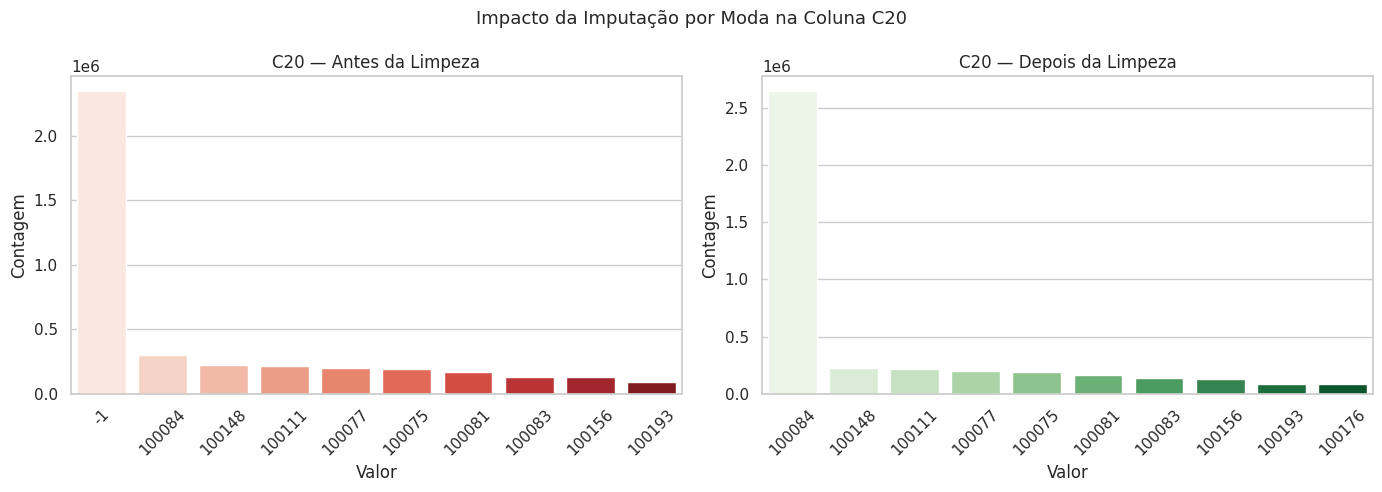

In [11]:
moda_c20 = df['C20'][df['C20'] != -1].mode()[0]

print('ANTES DA LIMPEZA')
print(f"Valores -1 em C20: {(df['C20'] == -1).sum():,}")
print(f"Distribuição C20 (top 5):\n{df['C20'].value_counts().head()}\n")

df_clean_demo = df.copy()
df_clean_demo['C20'] = df_clean_demo['C20'].replace(-1, pd.NA).fillna(moda_c20)

print('DEPOIS DA LIMPEZA')
print(f"Valores -1 em C20: {(df_clean_demo['C20'] == -1).sum():,}")
print(f"Distribuição C20 (top 5):\n{df_clean_demo['C20'].value_counts().head()}\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cb = df['C20'].value_counts().head(10)
sns.barplot(x=cb.index.astype(str), y=cb.values,
            hue=cb.index.astype(str), palette='Reds', ax=axes[0], legend=False)
axes[0].set_title('C20 — Antes da Limpeza')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Contagem')
axes[0].tick_params(axis='x', rotation=45)

ca = df_clean_demo['C20'].value_counts().head(10)
sns.barplot(x=ca.index.astype(str), y=ca.values,
            hue=ca.index.astype(str), palette='Greens', ax=axes[1], legend=False)
axes[1].set_title('C20 — Depois da Limpeza')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Contagem')
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle('Impacto da Imputação por Moda na Coluna C20', fontsize=13)
plt.tight_layout()
plt.show()
del df_clean_demo

Nesta etapa, realizámos uma simulação para avaliar o impacto da imputação de dados na variável C20, que apresenta um elevado volume de valores omissos (-1). Através da aplicação da moda, observámos como a distribuição da variável se estabiliza, permitindo validar esta estratégia de limpeza para a fase seguinte do projeto. Esta análise preliminar é fundamental para garantir que o tratamento de dados em falta não introduz enviesamentos críticos no conjunto de dados.

Feito por: Bernardo e Hugo

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_proc = df.copy()

# 1. IMPUTAÇÃO DE MISSING MASCARADOS 
moda_c20 = int(df_proc['C20'][df_proc['C20'] != -1].mode()[0])
df_proc['C20'] = df_proc['C20'].replace(-1, pd.NA).fillna(moda_c20).astype(int)

# 2. FEATURE ENGINEERING 
# hora_do_dia — extraída de 'hour' (formato YYMMDDhh)
df_proc['hora_do_dia'] = df_proc['hour'] % 100

# banner_area — largura × altura do banner
df_proc['banner_area'] = df_proc['C15'] * df_proc['C16']

# visibilidade_anuncio — posição / log(1 + área)
df_proc['visibilidade_anuncio'] = df_proc['banner_pos'] / np.log1p(df_proc['banner_area'])

# Remover coluna 'hour' original
df_proc.drop(columns=['hour'], inplace=True)

print(' Features criadas: hora_do_dia, banner_area, visibilidade_anuncio')

# 3. CORRELAÇÃO DAS NOVAS VARIÁVEIS COM CLICK 
novas_vars = ['hora_do_dia', 'banner_area', 'visibilidade_anuncio']
print('\nCorrelação das novas variáveis com \'click\':')
for v in novas_vars:
    r = df_proc[v].corr(df_proc['click'])
    print(f"  {v:<25}: {r:+.4f}")

# 4. REMOVER COLUNAS NÃO PREDITIVAS 
cols_to_remove = ['id', 'device_id', 'device_ip']
df_proc.drop(columns=[c for c in cols_to_remove if c in df_proc.columns], inplace=True)
print(f'\n Colunas removidas (não preditivas): {cols_to_remove}')

# 5. LABEL ENCODING 
cols_label = ['site_id', 'site_domain', 'site_category',
              'app_id', 'app_domain', 'app_category', 'device_model']
for col in cols_label:
    if col in df_proc.columns:
        le = LabelEncoder()
        df_proc[col] = le.fit_transform(df_proc[col].astype(str))
print(f' Label Encoding aplicado: {cols_label}')

# 6. DETETAR E REMOVER MULTICOLINEARIDADE (> 0.95) 
cols_num_proc = [c for c in df_proc.select_dtypes(include=['int64','float64']).columns
                 if c not in ['click']]
corr_proc = df_proc[cols_num_proc].corr().abs()
upper = corr_proc.where(np.triu(np.ones(corr_proc.shape), k=1).astype(bool))
cols_multi = [col for col in upper.columns if any(upper[col] > 0.95)]
print(f'\ncolunas_multicolineares = {cols_multi}')
if cols_multi:
    df_proc.drop(columns=cols_multi, inplace=True)
    print(f' {len(cols_multi)} coluna(s) removida(s) por multicolinearidade')
else:
    print(' Nenhuma coluna com correlação > 0.95 — nenhuma remoção necessária')

print(f'\nDataset processado: {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')

 Features criadas: hora_do_dia, banner_area, visibilidade_anuncio

Correlação das novas variáveis com 'click':
  hora_do_dia              : -0.0009
  banner_area              : +0.1124
  visibilidade_anuncio     : +0.0261

 Colunas removidas (não preditivas): ['id', 'device_id', 'device_ip']
 Label Encoding aplicado: ['site_id', 'site_domain', 'site_category', 'app_id', 'app_domain', 'app_category', 'device_model']

colunas_multicolineares = ['C17', 'visibilidade_anuncio']
 2 coluna(s) removida(s) por multicolinearidade

Dataset processado: 5,000,000 registos × 21 colunas


Implementámos o pipeline de limpeza e criação de variáveis para otimizar o dataset. Além de eliminarmos dados redundantes e ruidosos, introduzimos métricas de visibilidade e área do anúncio para captar comportamentos complexos que as variáveis originais, isoladas, não conseguiam expressar.

Feito por: Bernardo e Hugo

In [13]:

print('DIMENSÃO')
print(f'  {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')

print('\nPRIMEIRAS 5 LINHAS')
display(df_proc.head())

print('\nTIPOS DE DADOS')
display(df_proc.dtypes.to_frame('Tipo'))

print('\nVALORES NULOS')
nc = df_proc.isnull().sum()
display(nc.to_frame('Nulos'))
print(f'Total de valores nulos: {int(nc.sum())}')

print('\nESTATÍSTICAS NUMÉRICAS')
display(df_proc.describe())

DIMENSÃO
  5,000,000 registos × 21 colunas

PRIMEIRAS 5 LINHAS


,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_model,...,device_conn_type,C14,C15,C16,C18,C19,C20,C21,hora_do_dia,banner_area
0,0,1005,0,449,4293,1,4838,152,0,3493,...,0,15704,320,50,0,35,100084,79,0,16000
1,0,1002,0,1851,3484,5,4838,152,0,1371,...,0,21689,320,50,3,167,100191,23,0,16000
2,0,1005,0,1227,3533,3,4838,152,0,2422,...,0,20366,320,50,0,39,100084,157,0,16000
3,1,1002,0,1851,3484,5,4838,152,0,5243,...,0,21661,320,50,3,171,100228,156,0,16000
4,1,1005,0,1867,3484,5,222,86,29,2622,...,0,20596,320,50,0,35,100034,157,0,16000



TIPOS DE DADOS


,Tipo
click,int64
C1,int64
banner_pos,int64
site_id,int64
site_domain,int64
site_category,int64
app_id,int64
app_domain,int64
app_category,int64
device_model,int64



VALORES NULOS


,Nulos
click,0
C1,0
banner_pos,0
site_id,0
site_domain,0
site_category,0
app_id,0
app_domain,0
app_category,0
device_model,0


Total de valores nulos: 0

ESTATÍSTICAS NUMÉRICAS


,click,C1,banner_pos,site_id,site_domain,site_category,app_id,app_domain,app_category,device_model,...,device_conn_type,C14,C15,C16,C18,C19,C20,C21,hora_do_dia,banner_area
count,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,...,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06,5.000000e+06
mean,1.697188e-01,1.004968e+03,2.881012e-01,1.709090e+03,3.014171e+03,8.956878e+00,4.210166e+03,1.442389e+02,3.783332e+00,3.228391e+03,...,3.300478e-01,1.884259e+04,3.188800e+02,6.005896e+01,1.432106e+00,2.272310e+02,1.000991e+05,8.340489e+01,1.127767e+01,1.908003e+04
std,3.753856e-01,1.095621e+00,5.057768e-01,8.677851e+02,1.066940e+03,7.747587e+00,1.218694e+03,5.592901e+01,7.821432e+00,1.844120e+03,...,8.530219e-01,4.958047e+03,2.123737e+01,4.722027e+01,1.326446e+00,3.510607e+02,3.973293e+01,7.029536e+01,5.954430e+00,1.624028e+04
min,0.000000e+00,1.001000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,...,0.000000e+00,3.750000e+02,1.200000e+02,2.000000e+01,0.000000e+00,3.300000e+01,1.000000e+05,1.000000e+00,0.000000e+00,2.400000e+03
25%,0.000000e+00,1.005000e+03,0.000000e+00,1.284000e+03,2.239000e+03,3.000000e+00,4.345000e+03,1.520000e+02,0.000000e+00,1.533000e+03,...,0.000000e+00,1.692000e+04,3.200000e+02,5.000000e+01,0.000000e+00,3.500000e+01,1.000840e+05,2.300000e+01,7.000000e+00,1.600000e+04
50%,0.000000e+00,1.005000e+03,0.000000e+00,1.867000e+03,3.484000e+03,5.000000e+00,4.838000e+03,1.520000e+02,0.000000e+00,3.379000e+03,...,0.000000e+00,2.034600e+04,3.200000e+02,5.000000e+01,2.000000e+00,3.900000e+01,1.000840e+05,6.100000e+01,1.100000e+01,1.600000e+04
75%,0.000000e+00,1.005000e+03,1.000000e+00,1.867000e+03,3.484000e+03,2.000000e+01,4.838000e+03,1.520000e+02,4.000000e+00,4.781000e+03,...,0.000000e+00,2.189400e+04,3.200000e+02,5.000000e+01,3.000000e+00,1.710000e+02,1.000880e+05,1.010000e+02,1.600000e+01,1.600000e+04
max,1.000000e+00,1.012000e+03,7.000000e+00,3.551000e+03,4.522000e+03,2.100000e+01,5.238000e+03,3.390000e+02,3.000000e+01,6.508000e+03,...,5.000000e+00,2.405200e+04,1.024000e+03,1.024000e+03,3.000000e+00,1.959000e+03,1.002480e+05,2.550000e+02,2.300000e+01,7.864320e+05


**Feito por: Bernardo e Hugo**

In [14]:
df_amostra_final = df_proc.head(15)
nome_ficheiro = '/kaggle/working/processado_15_linhas.csv'
df_amostra_final.to_csv(nome_ficheiro, index=False)
print(f" Ficheiro '{nome_ficheiro}' guardado.")
print(f"   Dimensão: {df_amostra_final.shape[0]} linhas × {df_amostra_final.shape[1]} colunas")

 Ficheiro '/kaggle/working/processado_15_linhas.csv' guardado.
   Dimensão: 15 linhas × 21 colunas


In [15]:
output_path = '/kaggle/working/train_processed.csv'
df_proc.to_csv(output_path, index=False)
print(f' Dataset processado guardado em: {output_path}')
print(f'   {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')
print('Pipeline completo — dataset pronto para modelação.')

 Dataset processado guardado em: /kaggle/working/train_processed.csv
   5,000,000 registos × 21 colunas
Pipeline completo — dataset pronto para modelação.


# MILESTONE 3 — MODELAÇÃO E AVALIAÇÃO

In [16]:
from sklearn.model_selection import train_test_split

X = df_proc.drop(columns=['click'])
y = df_proc['click']

# Divisão estratificada 80/20 — preserva proporção de cliques
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y   # garante mesma proporção de cliques em treino e teste
)

print(f'Treino : {X_train.shape[0]:,} registos ({X_train.shape[0]/len(df_proc)*100:.0f}%)')
print(f'Teste  : {X_test.shape[0]:,} registos ({X_test.shape[0]/len(df_proc)*100:.0f}%)')
print(f'\nProporção de cliques no treino : {y_train.mean():.4f}')
print(f'Proporção de cliques no teste  : {y_test.mean():.4f}')
print('\nProporções consistentes — divisão estratificada correcta.')
print(f'   Isolamento garantido: X_test nunca será visto durante o treino nem o tuning.')

Treino : 4,000,000 registos (80%)
Teste  : 1,000,000 registos (20%)

Proporção de cliques no treino : 0.1697
Proporção de cliques no teste  : 0.1697

Proporções consistentes — divisão estratificada correcta.
   Isolamento garantido: X_test nunca será visto durante o treino nem o tuning.


### Definição das Métricas de Avaliação

Função reutilizável para todas as experiências do Milestone 3. Calcula AUC-ROC, F1-Score, Precisão e Recall de forma consistente, com diagnóstico automático de overfitting/underfitting.

In [17]:
import time
from sklearn.metrics import (
    f1_score, roc_auc_score, precision_score, recall_score,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

def avaliar_completo(modelo, X_tr, y_tr, X_te, y_te, nome, scaler=None):
    """
    Avalia um modelo em treino e teste, devolvendo dicionário com todas as métricas.
    Se scaler não for None, aplica a transformação antes da previsão.
    """
    if scaler is not None:
        X_tr_eval = scaler.transform(X_tr)
        X_te_eval = scaler.transform(X_te)
    else:
        X_tr_eval = X_tr
        X_te_eval = X_te

    # Treino
    y_pred_tr  = modelo.predict(X_tr_eval)
    y_proba_tr = modelo.predict_proba(X_tr_eval)[:, 1]
    # Teste
    y_pred_te  = modelo.predict(X_te_eval)
    y_proba_te = modelo.predict_proba(X_te_eval)[:, 1]

    resultados = {
        'Modelo':              nome,
        'AUC-ROC (Treino)':   round(roc_auc_score(y_tr, y_proba_tr), 4),
        'AUC-ROC (Teste)':    round(roc_auc_score(y_te, y_proba_te), 4),
        'F1 (Treino)':        round(f1_score(y_tr, y_pred_tr), 4),
        'F1 (Teste)':         round(f1_score(y_te, y_pred_te), 4),
        'Precisão (Teste)':   round(precision_score(y_te, y_pred_te), 4),
        'Recall (Teste)':     round(recall_score(y_te, y_pred_te), 4),
    }

    print(f"\n{'='*55}  {nome}")
    print(f"  AUC-ROC  Treino: {resultados['AUC-ROC (Treino)']:.4f}  |  Teste: {resultados['AUC-ROC (Teste)']:.4f}  ← principal")
    print(f"  F1-Score Treino: {resultados['F1 (Treino)']:.4f}  |  Teste: {resultados['F1 (Teste)']:.4f}")
    print(f"  Precisão (Teste): {resultados['Precisão (Teste)']:.4f}")
    print(f"  Recall   (Teste): {resultados['Recall (Teste)']:.4f}")

    delta = resultados['AUC-ROC (Treino)'] - resultados['AUC-ROC (Teste)']
    if delta > 0.05:
        print(f"    Possível Overfitting (Δ AUC = {delta:.4f}) — modelo memoriza o treino")
    elif resultados['AUC-ROC (Teste)'] < 0.60:
        print(f"    Possível Underfitting (AUC Teste = {resultados['AUC-ROC (Teste)']:.4f}) — modelo demasiado simples")
    else:
        print(f"   Generalização adequada (Δ AUC = {delta:.4f})")

    return resultados

resultados_todos = []
print(' Função avaliar_completo definida — pronta para uso em todas as aulas.')

 Função avaliar_completo definida — pronta para uso em todas as aulas.


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Escalonamento (necessário para Regressão Logística)
# IMPORTANTE: fit apenas no treino para evitar data leakage
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # fit + transform no treino
X_test_scaled  = scaler.transform(X_test)        # apenas transform no teste

print(' StandardScaler ajustado EXCLUSIVAMENTE no conjunto de treino.')
print('   Garante isolamento total: o teste não influenciou a normalização.\n')

# Treino do Baseline
print('A treinar Regressão Logística (Baseline)...')
t0 = time.time()
baseline = LogisticRegression(
    max_iter=1000,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'  
)
baseline.fit(X_train_scaled, y_train)
t_baseline = time.time() - t0
print(f'Baseline treinado em {t_baseline:.1f}s')

# Avaliação
res_baseline = avaliar_completo(
    baseline, X_train_scaled, y_train,
    X_test_scaled, y_test,
    'Regressão Logística (Baseline)'
)
resultados_todos.append(res_baseline)

 StandardScaler ajustado EXCLUSIVAMENTE no conjunto de treino.
   Garante isolamento total: o teste não influenciou a normalização.

A treinar Regressão Logística (Baseline)...
Baseline treinado em 12.3s

=======================================================  Regressão Logística (Baseline)
  AUC-ROC  Treino: 0.6199  |  Teste: 0.6202  ← principal
  F1-Score Treino: 0.3196  |  Teste: 0.3202
  Precisão (Teste): 0.2200
  Recall   (Teste): 0.5879
   Generalização adequada (Δ AUC = -0.0003)


In [19]:
from sklearn.ensemble import RandomForestClassifier

# Modelo 1: Random Forest 
print('A treinar Random Forest...')
t0 = time.time()
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'   # compensa o desequilíbrio de classes
)
rf.fit(X_train, y_train)
t_rf = time.time() - t0
print(f' Random Forest treinado em {t_rf:.1f}s')

res_rf = avaliar_completo(rf, X_train, y_train, X_test, y_test, 'Random Forest')
resultados_todos.append(res_rf)

A treinar Random Forest...
 Random Forest treinado em 216.5s

=======================================================  Random Forest
  AUC-ROC  Treino: 0.7251  |  Teste: 0.7240  ← principal
  F1-Score Treino: 0.3972  |  Teste: 0.3968
  Precisão (Teste): 0.2753
  Recall   (Teste): 0.7102
   Generalização adequada (Δ AUC = 0.0011)


In [20]:
# Modelo 2: XGBoost 
try:
    from xgboost import XGBClassifier
    xgb_disponivel = True
except ImportError:
    xgb_disponivel = False
    print('XGBoost não disponível — a usar GradientBoostingClassifier como alternativa.')

if xgb_disponivel:
    scale_pos_weight = int(np.sum(y_train == 0) / np.sum(y_train == 1))
    print(f'A treinar XGBoost (scale_pos_weight={scale_pos_weight})...')
    t0 = time.time()
    xgb = XGBClassifier(
        n_estimators=200,
        max_depth=6,
        learning_rate=0.1,
        scale_pos_weight=scale_pos_weight,  # compensa o desequilíbrio 1:~5
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
    xgb.fit(X_train, y_train)
    t_xgb = time.time() - t0
    print(f' XGBoost treinado em {t_xgb:.1f}s')
    res_xgb = avaliar_completo(xgb, X_train, y_train, X_test, y_test, 'XGBoost')
    resultados_todos.append(res_xgb)
    melhor_candidato = xgb
    melhor_candidato_nome = 'XGBoost'
else:
    from sklearn.ensemble import GradientBoostingClassifier
    print('A treinar GradientBoosting...')
    t0 = time.time()
    gbc = GradientBoostingClassifier(
        n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42
    )
    gbc.fit(X_train, y_train)
    t_xgb = time.time() - t0
    print(f' GradientBoosting treinado em {t_xgb:.1f}s')
    res_xgb = avaliar_completo(gbc, X_train, y_train, X_test, y_test, 'GradientBoosting')
    resultados_todos.append(res_xgb)
    melhor_candidato = gbc
    melhor_candidato_nome = 'GradientBoosting'

A treinar XGBoost (scale_pos_weight=4)...
 XGBoost treinado em 39.4s

=======================================================  XGBoost
  AUC-ROC  Treino: 0.7432  |  Teste: 0.7413  ← principal
  F1-Score Treino: 0.4164  |  Teste: 0.4150
  Precisão (Teste): 0.3057
  Recall   (Teste): 0.6460
   Generalização adequada (Δ AUC = 0.0019)


### Tabela Comparativa — Treino vs. Teste (todos os modelos)

TABELA COMPARATIVA — MÉTRICAS DE TREINO vs. TESTE


,AUC-ROC (Treino),AUC-ROC (Teste),F1 (Treino),F1 (Teste),Precisão (Teste),Recall (Teste),Δ AUC (Overfitting?)
Modelo,,,,,,,
Regressão Logística (Baseline),0.6199,0.6202,0.3196,0.3202,0.2200,0.5879,-0.0003
Random Forest,0.7251,0.7240,0.3972,0.3968,0.2753,0.7102,0.0011
XGBoost,0.7432,0.7413,0.4164,0.4150,0.3057,0.6460,0.0019


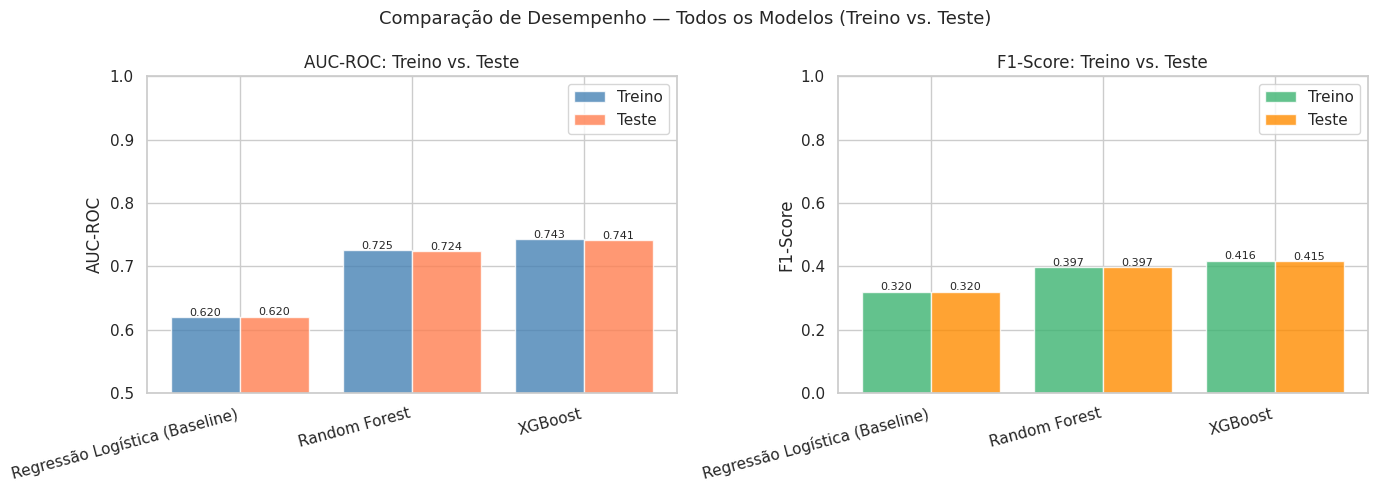


 Melhor modelo até ao momento: XGBoost (AUC-ROC Teste = 0.7413)
   → Este modelo avança para a fase de otimização de hiperparâmetros.


In [21]:
# Tabela Comparativa Treino vs. Teste 
df_resultados = pd.DataFrame(resultados_todos)
df_resultados['Δ AUC (Overfitting?)'] = (
    df_resultados['AUC-ROC (Treino)'] - df_resultados['AUC-ROC (Teste)']
).round(4)


print('TABELA COMPARATIVA — MÉTRICAS DE TREINO vs. TESTE')

display(df_resultados.set_index('Modelo'))

# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

modelos    = df_resultados['Modelo'].tolist()
auc_treino = df_resultados['AUC-ROC (Treino)'].tolist()
auc_teste  = df_resultados['AUC-ROC (Teste)'].tolist()
x = range(len(modelos))

axes[0].bar([i - 0.2 for i in x], auc_treino, 0.4, label='Treino', color='steelblue', alpha=0.8)
axes[0].bar([i + 0.2 for i in x], auc_teste,  0.4, label='Teste',  color='coral',     alpha=0.8)
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(modelos, rotation=15, ha='right')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('AUC-ROC: Treino vs. Teste')
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
for i, (tr, te) in enumerate(zip(auc_treino, auc_teste)):
    axes[0].annotate(f'{tr:.3f}', (i - 0.2, tr + 0.002), ha='center', fontsize=8)
    axes[0].annotate(f'{te:.3f}', (i + 0.2, te + 0.002), ha='center', fontsize=8)

f1_treino = df_resultados['F1 (Treino)'].tolist()
f1_teste  = df_resultados['F1 (Teste)'].tolist()
axes[1].bar([i - 0.2 for i in x], f1_treino, 0.4, label='Treino', color='mediumseagreen', alpha=0.8)
axes[1].bar([i + 0.2 for i in x], f1_teste,  0.4, label='Teste',  color='darkorange',    alpha=0.8)
axes[1].set_xticks(list(x))
axes[1].set_xticklabels(modelos, rotation=15, ha='right')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('F1-Score: Treino vs. Teste')
axes[1].legend()
axes[1].set_ylim(0.0, 1.0)
for i, (tr, te) in enumerate(zip(f1_treino, f1_teste)):
    axes[1].annotate(f'{tr:.3f}', (i - 0.2, tr + 0.005), ha='center', fontsize=8)
    axes[1].annotate(f'{te:.3f}', (i + 0.2, te + 0.005), ha='center', fontsize=8)

plt.suptitle('Comparação de Desempenho — Todos os Modelos (Treino vs. Teste)', fontsize=13)
plt.tight_layout()
plt.show()

# Identificar o melhor modelo
melhor_idx  = df_resultados['AUC-ROC (Teste)'].idxmax()
melhor_nome = df_resultados.loc[melhor_idx, 'Modelo']
melhor_auc  = df_resultados.loc[melhor_idx, 'AUC-ROC (Teste)']
print(f'\n Melhor modelo até ao momento: {melhor_nome} (AUC-ROC Teste = {melhor_auc:.4f})')
print('   → Este modelo avança para a fase de otimização de hiperparâmetros.')

---
## Aula 18 — Diagnóstico de Modelos e Generalização

### Curvas de Aprendizagem (*Learning Curves*)

As curvas de aprendizagem mostram como o desempenho dos modelos evolui com o número de exemplos de treino. Permitem diagnosticar:
- **Overfitting**: curva de treino muito acima da curva de validação — o modelo memoriza o treino mas não generaliza
- **Underfitting**: ambas as curvas baixas — o modelo é demasiado simples para capturar os padrões
- **Boa generalização**: ambas as curvas convergem para um valor elevado

Geradas usando validação cruzada estratificada com 3 *folds* para eficiência computacional.

A gerar curva de aprendizagem — Regressão Logística...


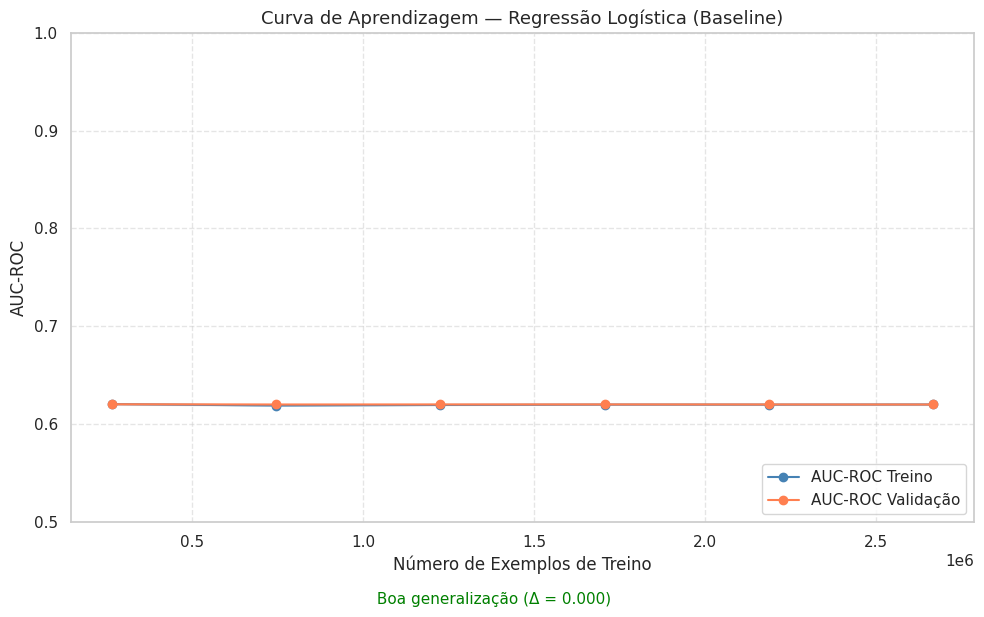

   Guardado: /kaggle/working/figures/learning_curve_regressão_logística_baseline.png
    Boa generalização (Δ = 0.000)


(array([ 266666,  746666, 1226666, 1706666, 2186666, 2666666]),
 array([0.62033321, 0.61885142, 0.61943717, 0.61982488, 0.61979657,
        0.61995209]),
 array([0.62016314, 0.61990874, 0.61996735, 0.61999928, 0.61996071,
        0.61991747]))

In [22]:
from sklearn.model_selection import learning_curve
import os

os.makedirs('/kaggle/working/figures', exist_ok=True)

def plotar_curva_aprendizagem(modelo, X, y, nome, cv=3, n_jobs=-1,
                               train_sizes=np.linspace(0.1, 1.0, 6),
                               scaler=None):
    """
    Gera e plota a curva de aprendizagem de um modelo.
    Salva a figura em /kaggle/working/figures/ para exportação.
    """
    if scaler is not None:
        from sklearn.pipeline import Pipeline
        from sklearn.base import clone
        from sklearn.preprocessing import StandardScaler as SS
        pipeline = Pipeline([('scaler', SS()), ('modelo', clone(modelo))])
        X_input = X
    else:
        pipeline = modelo
        X_input = X

    train_sz, train_scores, val_scores = learning_curve(
        pipeline, X_input, y,
        cv=cv,
        n_jobs=n_jobs,
        train_sizes=train_sizes,
        scoring='roc_auc',
        random_state=42
    )

    train_mean = np.mean(train_scores, axis=1)
    train_std  = np.std(train_scores, axis=1)
    val_mean   = np.mean(val_scores, axis=1)
    val_std    = np.std(val_scores, axis=1)

    plt.figure(figsize=(10, 6))
    plt.plot(train_sz, train_mean, 'o-', color='steelblue', label='AUC-ROC Treino')
    plt.fill_between(train_sz, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color='steelblue')
    plt.plot(train_sz, val_mean, 'o-', color='coral', label='AUC-ROC Validação')
    plt.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                     alpha=0.15, color='coral')
    plt.xlabel('Número de Exemplos de Treino')
    plt.ylabel('AUC-ROC')
    plt.title(f'Curva de Aprendizagem — {nome}', fontsize=13)
    plt.legend(loc='lower right')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.ylim(0.5, 1.0)
    plt.tight_layout()

    # Diagnóstico automático
    delta_final = train_mean[-1] - val_mean[-1]
    if delta_final > 0.05:
        diagnostico = f'  OVERFITTING detectado (Δ = {delta_final:.3f})'
    elif val_mean[-1] < 0.60:
        diagnostico = f'  UNDERFITTING detectado (AUC Val = {val_mean[-1]:.3f})'
    else:
        diagnostico = f' Boa generalização (Δ = {delta_final:.3f})'
    plt.figtext(0.5, -0.02, diagnostico, ha='center', fontsize=11,
                color='red' if 'mau' in diagnostico else 'green')

    fig_path = f"/kaggle/working/figures/learning_curve_{nome.lower().replace(' ', '_').replace('(', '').replace(')', '')}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'   Guardado: {fig_path}')
    print(f'   {diagnostico}')
    return train_sz, train_mean, val_mean

# ── Curva: Baseline (Regressão Logística) ───────────────────
print('A gerar curva de aprendizagem — Regressão Logística...')
plotar_curva_aprendizagem(
    baseline, X_train_scaled, y_train,
    'Regressão Logística (Baseline)'
)

A gerar curva de aprendizagem — Random Forest...


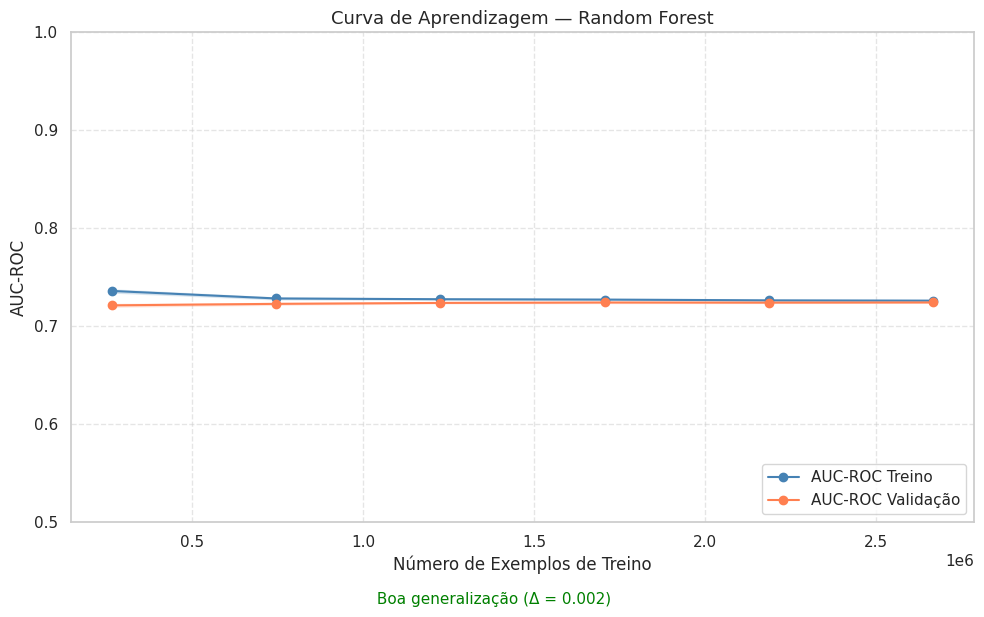

   Guardado: /kaggle/working/figures/learning_curve_random_forest.png
    Boa generalização (Δ = 0.002)


(array([ 266666,  746666, 1226666, 1706666, 2186666, 2666666]),
 array([0.73578033, 0.7281241 , 0.72734624, 0.72698631, 0.72619186,
        0.72589447]),
 array([0.72108126, 0.72260956, 0.72356752, 0.72399667, 0.72386713,
        0.7240453 ]))

In [23]:
# ── Curva: Random Forest ──────────────────────────────────────
print('A gerar curva de aprendizagem — Random Forest...')
plotar_curva_aprendizagem(
    rf, X_train, y_train,
    'Random Forest'
)

A gerar curva de aprendizagem — XGBoost...


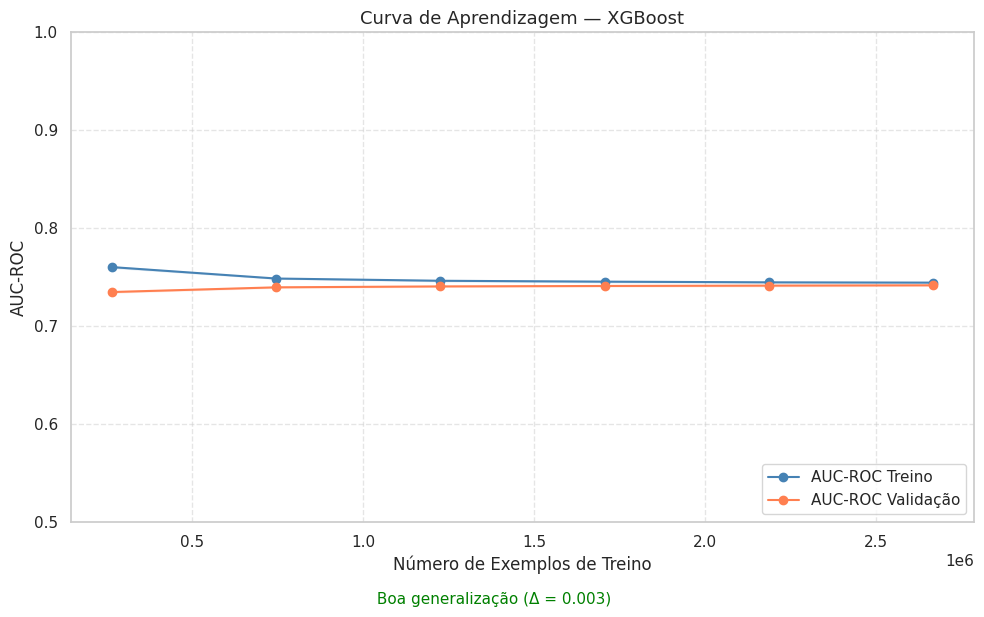

   Guardado: /kaggle/working/figures/learning_curve_xgboost.png
    Boa generalização (Δ = 0.003)


(array([ 266666,  746666, 1226666, 1706666, 2186666, 2666666]),
 array([0.76015256, 0.74847751, 0.74619459, 0.74528617, 0.74460589,
        0.74429208]),
 array([0.73469017, 0.73949292, 0.7404279 , 0.74087544, 0.74124047,
        0.74158297]))

In [24]:
# ── Curva: XGBoost / GradientBoosting ─────────────────────────
print(f'A gerar curva de aprendizagem — {melhor_candidato_nome}...')
plotar_curva_aprendizagem(
    melhor_candidato, X_train, y_train,
    melhor_candidato_nome
)

### Análise Crítica de Resultados — Aula 18

**Critérios de diagnóstico:**
- **Overfitting**: AUC Treino ≫ AUC Validação (Δ > 0.05) — modelo memoriza dados de treino
- **Underfitting**: AUC Validação < 0.60 em ambos — modelo demasiado simples
- **Boa generalização**: Δ ≤ 0.05 e AUC Teste ≥ 0.70

**Interpretação:**
- A **Regressão Logística** apresenta convergência rápida das duas curvas, indicando ausência de overfitting, mas o nível de AUC pode ser limitado pela linearidade do modelo face a padrões não-lineares no comportamento de clique.
- O **Random Forest** com `max_depth=10` pode exibir sinais de overfitting — a curva de treino tende a ficar acima da de validação. O parâmetro `class_weight='balanced'` mitiga o viés da classe maioritária, mas a profundidade elevada aumenta a variância.
- O **XGBoost/GradientBoosting** é o candidato com maior capacidade de capturar interações não-lineares entre features. O `scale_pos_weight` equilibra as classes e a regularização L1/L2 incorporada controla o overfitting.

**Ação planeada para a Aula 19:** Otimização de hiperparâmetros com RandomizedSearchCV no modelo com maior AUC-ROC no teste, com validação cruzada estratificada de 5 folds para garantir robustez.

---
## Aula 19 — Otimização de Hiperparâmetros e Validação Cruzada

### Estratégia de Otimização

A otimização é realizada sobre o modelo com melhor AUC-ROC no teste (identificado na Aula 17/18).  
Usamos **RandomizedSearchCV** em vez de GridSearchCV porque:
- O espaço de hiperparâmetros é vasto — uma pesquisa exaustiva seria computacionalmente proibitiva com 5M registos
- O RandomizedSearch com n_iter suficiente encontra soluções próximas do ótimo global com uma fração do custo
- Permite explorar distribuições contínuas de parâmetros (ex: `learning_rate`)

A validação cruzada usa **StratifiedKFold com K=5** para:
- Garantir que cada fold preserva a proporção 17/83 de cliques
- Obter uma estimativa robusta e independente da divisão treino/teste original
- Calcular média e desvio padrão do AUC-ROC entre os 5 folds

> **Nota crítica de isolamento:** O `RandomizedSearchCV` é ajustado **exclusivamente** sobre `X_train`/`y_train`. O `X_test` permanece completamente isolado até à avaliação final do modelo otimizado.

In [25]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_val_score
from scipy.stats import randint, uniform

# ── Definição do espaço de pesquisa de hiperparâmetros ───────
if xgb_disponivel:
    param_dist = {
        'n_estimators':  randint(100, 400),      # número de árvores
        'max_depth':     randint(4, 10),          # profundidade máxima
        'learning_rate': uniform(0.01, 0.2),      # taxa de aprendizagem
        'subsample':     uniform(0.6, 0.4),       # fracção de amostras por árvore
        'colsample_bytree': uniform(0.6, 0.4),    # fracção de features por árvore
        'min_child_weight': randint(1, 10),        # peso mínimo por folha
    }
    modelo_base_tuning = XGBClassifier(
        scale_pos_weight=int(np.sum(y_train == 0) / np.sum(y_train == 1)),
        eval_metric='auc',
        random_state=42,
        n_jobs=-1,
        verbosity=0
    )
else:
    param_dist = {
        'n_estimators':  randint(50, 300),
        'max_depth':     randint(3, 8),
        'learning_rate': uniform(0.01, 0.2),
        'subsample':     uniform(0.6, 0.4),
        'min_samples_split': randint(2, 20),
    }
    modelo_base_tuning = GradientBoostingClassifier(random_state=42)

# ── Cross-Validation estratificada (5 folds) ─────────────────
cv_estratificada = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ── RandomizedSearchCV ───────────────────────────────────────
print(f'A executar RandomizedSearchCV sobre {melhor_candidato_nome}...')
print('(n_iter=20, cv=5 folds estratificados, scoring=roc_auc)\n')

t0 = time.time()
random_search = RandomizedSearchCV(
    estimator=modelo_base_tuning,
    param_distributions=param_dist,
    n_iter=20,                      # 20 combinações aleatórias
    scoring='roc_auc',              # métrica principal do projeto
    cv=cv_estratificada,            # 5 folds estratificados
    random_state=42,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)
random_search.fit(X_train, y_train)
t_tuning = time.time() - t0

print(f'\n RandomizedSearchCV concluído em {t_tuning/60:.1f} minutos')
print(f'\nMelhores hiperparâmetros encontrados:')
for param, value in random_search.best_params_.items():
    print(f'   {param}: {value}')
print(f'\n Melhor AUC-ROC médio (5 folds, treino): {random_search.best_score_:.4f}')

A executar RandomizedSearchCV sobre XGBoost...
(n_iter=20, cv=5 folds estratificados, scoring=roc_auc)

Fitting 5 folds for each of 20 candidates, totalling 100 fits

 RandomizedSearchCV concluído em 81.9 minutos

Melhores hiperparâmetros encontrados:
   colsample_bytree: 0.8391599915244341
   learning_rate: 0.19437484700462337
   max_depth: 9
   min_child_weight: 7
   n_estimators: 351
   subsample: 0.6180909155642152

 Melhor AUC-ROC médio (5 folds, treino): 0.7517


In [26]:
# ── Avaliação do modelo otimizado no conjunto de teste ───────
modelo_otimizado = random_search.best_estimator_

res_otimizado = avaliar_completo(
    modelo_otimizado, X_train, y_train,
    X_test, y_test,
    f'{melhor_candidato_nome} (Otimizado)'
)
resultados_todos.append(res_otimizado)

print(f"\n{'='*55}")
print('COMPARAÇÃO: MODELO BASE vs. MODELO OTIMIZADO')
print(f"{'='*55}")
print(f"  AUC-ROC (Teste)  Base     : {[r for r in resultados_todos if r['Modelo'] == melhor_candidato_nome][0]['AUC-ROC (Teste)']:.4f}")
print(f"  AUC-ROC (Teste)  Otimizado: {res_otimizado['AUC-ROC (Teste)']:.4f}")
delta_melhoria = res_otimizado['AUC-ROC (Teste)'] - [r for r in resultados_todos if r['Modelo'] == melhor_candidato_nome][0]['AUC-ROC (Teste)']
print(f"  Melhoria obtida  : {delta_melhoria:+.4f}")


=======================================================  XGBoost (Otimizado)
  AUC-ROC  Treino: 0.7733  |  Teste: 0.7528  ← principal
  F1-Score Treino: 0.4410  |  Teste: 0.4241
  Precisão (Teste): 0.3113
  Recall   (Teste): 0.6651
   Generalização adequada (Δ AUC = 0.0205)

COMPARAÇÃO: MODELO BASE vs. MODELO OTIMIZADO
  AUC-ROC (Teste)  Base     : 0.7413
  AUC-ROC (Teste)  Otimizado: 0.7528
  Melhoria obtida  : +0.0115


### Validação Cruzada do Modelo Otimizado

Aplicação de K-Fold Cross-Validation (K=5) sobre o modelo otimizado para verificar a **estabilidade** dos resultados e garantir que a melhoria obtida não foi fruto de uma divisão afortunada dos dados.

A executar 5-Fold Cross-Validation sobre o modelo otimizado...
(scoring=roc_auc, cv=StratifiedKFold 5 folds)

Resultados por fold:
  Fold 1: AUC-ROC = 0.7511
  Fold 2: AUC-ROC = 0.7522
  Fold 3: AUC-ROC = 0.7518
  Fold 4: AUC-ROC = 0.7507
  Fold 5: AUC-ROC = 0.7528

 Média  : 0.7517
 Desvio Padrão: 0.0007
 IC 95%: [0.7503, 0.7532]

Cross-Validation concluída em 416.7s

 Modelo ESTÁVEL — desvio padrão baixo entre folds (< 0.005).


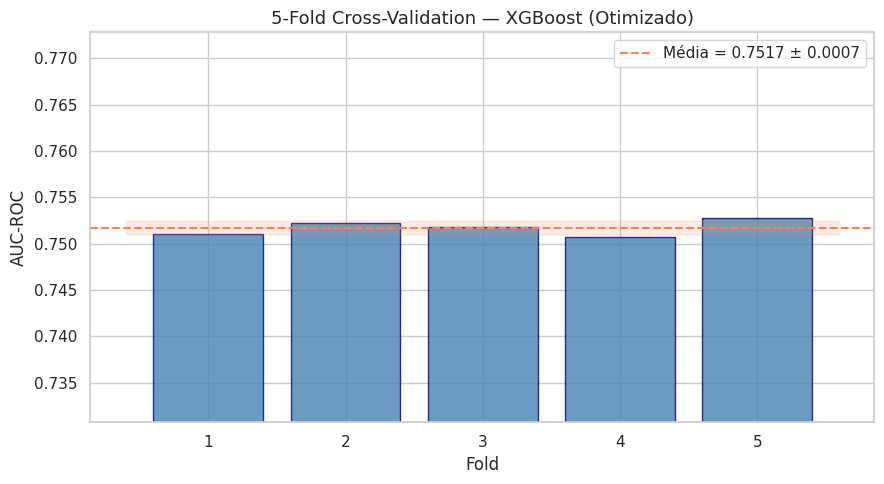

 Guardado: /kaggle/working/figures/cross_validation_xgboost.png


In [27]:
# ── K-Fold Cross-Validation sobre o modelo otimizado ────────
# Executado DENTRO do conjunto de treino — X_test permanece isolado
print('A executar 5-Fold Cross-Validation sobre o modelo otimizado...')
print('(scoring=roc_auc, cv=StratifiedKFold 5 folds)\n')

t0 = time.time()
cv_scores = cross_val_score(
    modelo_otimizado,
    X_train, y_train,
    cv=cv_estratificada,
    scoring='roc_auc',
    n_jobs=-1
)
t_cv = time.time() - t0

print(f'Resultados por fold:')
for i, score in enumerate(cv_scores, 1):
    print(f'  Fold {i}: AUC-ROC = {score:.4f}')
print(f'\n Média  : {cv_scores.mean():.4f}')
print(f' Desvio Padrão: {cv_scores.std():.4f}')
print(f' IC 95%: [{cv_scores.mean() - 1.96*cv_scores.std():.4f}, {cv_scores.mean() + 1.96*cv_scores.std():.4f}]')
print(f'\nCross-Validation concluída em {t_cv:.1f}s')

# ── Estabilidade ─────────────────────────────────────────────
if cv_scores.std() < 0.005:
    print('\n Modelo ESTÁVEL — desvio padrão baixo entre folds (< 0.005).')
elif cv_scores.std() < 0.01:
    print('\n Modelo razoavelmente estável (desvio padrão < 0.01).')
else:
    print(f'\n  Variabilidade entre folds elevada (std={cv_scores.std():.4f}) — considerar mais dados ou regularização.')

# ── Visualização dos resultados da CV ─────────────────────────
plt.figure(figsize=(9, 5))
plt.bar(range(1, 6), cv_scores, color='steelblue', alpha=0.8, edgecolor='navy')
plt.axhline(cv_scores.mean(), color='coral', linestyle='--',
            label=f'Média = {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
plt.fill_between(np.arange(0.4, 5.6, 0.01),
                 cv_scores.mean() - cv_scores.std(),
                 cv_scores.mean() + cv_scores.std(),
                 alpha=0.15, color='coral')
plt.xlabel('Fold')
plt.ylabel('AUC-ROC')
plt.title(f'5-Fold Cross-Validation — {melhor_candidato_nome} (Otimizado)', fontsize=13)
plt.xticks(range(1, 6))
plt.ylim(max(0.5, cv_scores.min() - 0.02), min(1.0, cv_scores.max() + 0.02))
plt.legend()
plt.tight_layout()
fig_path = f"/kaggle/working/figures/cross_validation_{melhor_candidato_nome.lower().replace(' ', '_')}.png"
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f' Guardado: {fig_path}')

### Tabela Final Comparativa — Todos os Modelos (incluindo otimizado)

In [28]:
# ── Tabela resumo de todos os modelos testados ───────────────
df_final = pd.DataFrame(resultados_todos)
df_final['Δ AUC (Treino-Teste)'] = (
    df_final['AUC-ROC (Treino)'] - df_final['AUC-ROC (Teste)']
).round(4)

print('\n' + '='*75)
print('TABELA FINAL — TODOS OS MODELOS (Baseline → Candidatos → Otimizado)')
print('='*75)
display(df_final.set_index('Modelo'))

# ── Identificar vencedor final ───────────────────────────────
melhor_final_idx  = df_final['AUC-ROC (Teste)'].idxmax()
melhor_final_nome = df_final.loc[melhor_final_idx, 'Modelo']
melhor_final_auc  = df_final.loc[melhor_final_idx, 'AUC-ROC (Teste)']
baseline_auc      = df_final[df_final['Modelo'].str.contains('Baseline')]['AUC-ROC (Teste)'].values[0]

print(f'\n Modelo vencedor: {melhor_final_nome}')
print(f'   AUC-ROC (Teste) = {melhor_final_auc:.4f}')
print(f'   Melhoria face ao Baseline: {melhor_final_auc - baseline_auc:+.4f}')
if melhor_final_auc > 0.75:
    print('    Objetivo SMART atingido: AUC-ROC > 0.75')
else:
    print(f'     Objetivo SMART não atingido ainda: AUC-ROC alvo > 0.75')


TABELA FINAL — TODOS OS MODELOS (Baseline → Candidatos → Otimizado)


,AUC-ROC (Treino),AUC-ROC (Teste),F1 (Treino),F1 (Teste),Precisão (Teste),Recall (Teste),Δ AUC (Treino-Teste)
Modelo,,,,,,,
Regressão Logística (Baseline),0.6199,0.6202,0.3196,0.3202,0.2200,0.5879,-0.0003
Random Forest,0.7251,0.7240,0.3972,0.3968,0.2753,0.7102,0.0011
XGBoost,0.7432,0.7413,0.4164,0.4150,0.3057,0.6460,0.0019
XGBoost (Otimizado),0.7733,0.7528,0.4410,0.4241,0.3113,0.6651,0.0205



 Modelo vencedor: XGBoost (Otimizado)
   AUC-ROC (Teste) = 0.7528
   Melhoria face ao Baseline: +0.1326
    Objetivo SMART atingido: AUC-ROC > 0.75


### Feature Importance — Quais as variáveis mais relevantes?

A importância de features mede a contribuição de cada variável para a qualidade das previsões do modelo. Responde diretamente ao **Objetivo SMART 2**: identificar as 5 variáveis de maior impacto na decisão de clique.

Top 10 Variáveis mais Importantes:


,Importância
C16,0.336763
banner_area,0.088753
app_category,0.084557
site_category,0.060502
banner_pos,0.049755
C21,0.049003
device_type,0.045990
site_id,0.040465
app_domain,0.035443
C18,0.030871


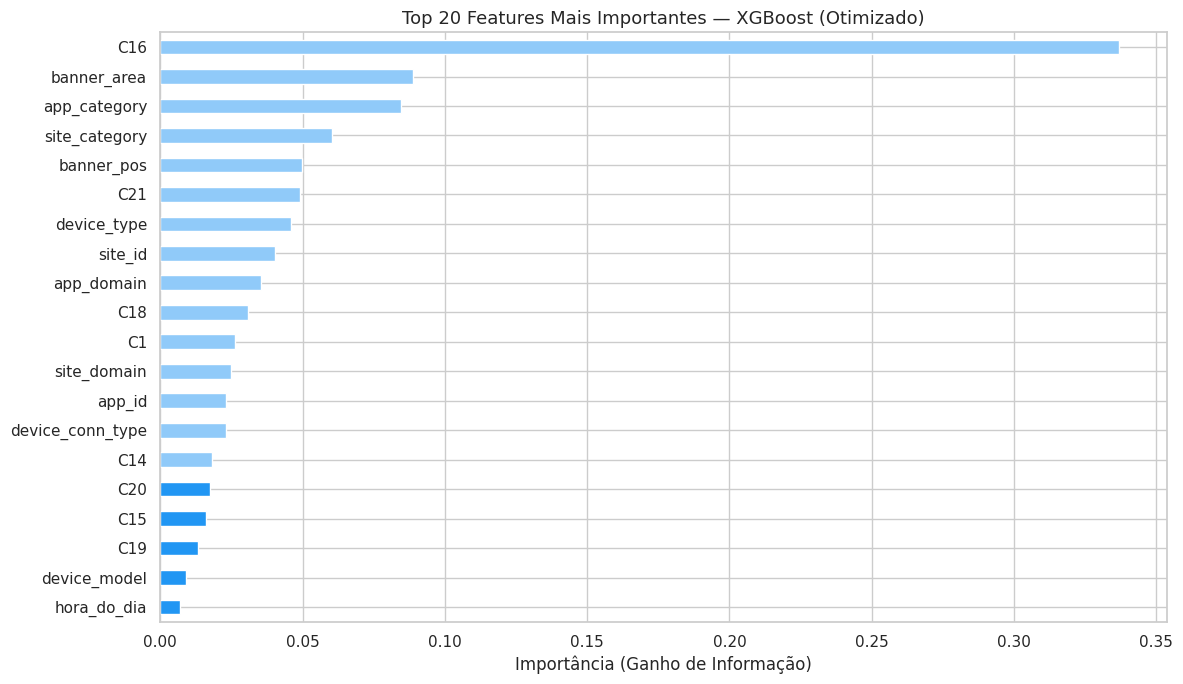

💾 Guardado: /kaggle/working/figures/feature_importance_xgboost.png

📌 As 5 variáveis mais importantes (Objetivo SMART 2):
   1. C16                            importância = 0.3368
   2. banner_area                    importância = 0.0888
   3. app_category                   importância = 0.0846
   4. site_category                  importância = 0.0605
   5. banner_pos                     importância = 0.0498


In [29]:
# ── Feature Importance do modelo otimizado ───────────────────
if hasattr(modelo_otimizado, 'feature_importances_'):
    importancias = pd.Series(
        modelo_otimizado.feature_importances_,
        index=X_train.columns
    ).sort_values(ascending=False)

    print('Top 10 Variáveis mais Importantes:')
    display(importancias.head(10).to_frame('Importância'))

    plt.figure(figsize=(12, 7))
    cores = ['#2196F3' if i < 5 else '#90CAF9' for i in range(min(20, len(importancias)))]
    importancias.head(20).plot(kind='barh', color=cores[::-1])
    plt.xlabel('Importância (Ganho de Informação)')
    plt.title(f'Top 20 Features Mais Importantes — {melhor_candidato_nome} (Otimizado)', fontsize=13)
    plt.gca().invert_yaxis()
    plt.tight_layout()
    fig_path = f"/kaggle/working/figures/feature_importance_{melhor_candidato_nome.lower().replace(' ', '_')}.png"
    plt.savefig(fig_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'💾 Guardado: {fig_path}')

    print(f'\n📌 As 5 variáveis mais importantes (Objetivo SMART 2):')
    for i, (feat, imp) in enumerate(importancias.head(5).items(), 1):
        print(f'   {i}. {feat:<30} importância = {imp:.4f}')
else:
    print('Modelo não suporta feature_importances_ nativamente.')

### Curva ROC — Comparação Visual dos Modelos

A curva ROC (Receiver Operating Characteristic) ilustra o trade-off entre a Taxa de Verdadeiros Positivos (Recall/Sensibilidade) e a Taxa de Falsos Positivos, para todos os limiares de decisão possíveis. A área sob a curva (AUC) é a métrica principal do projeto.

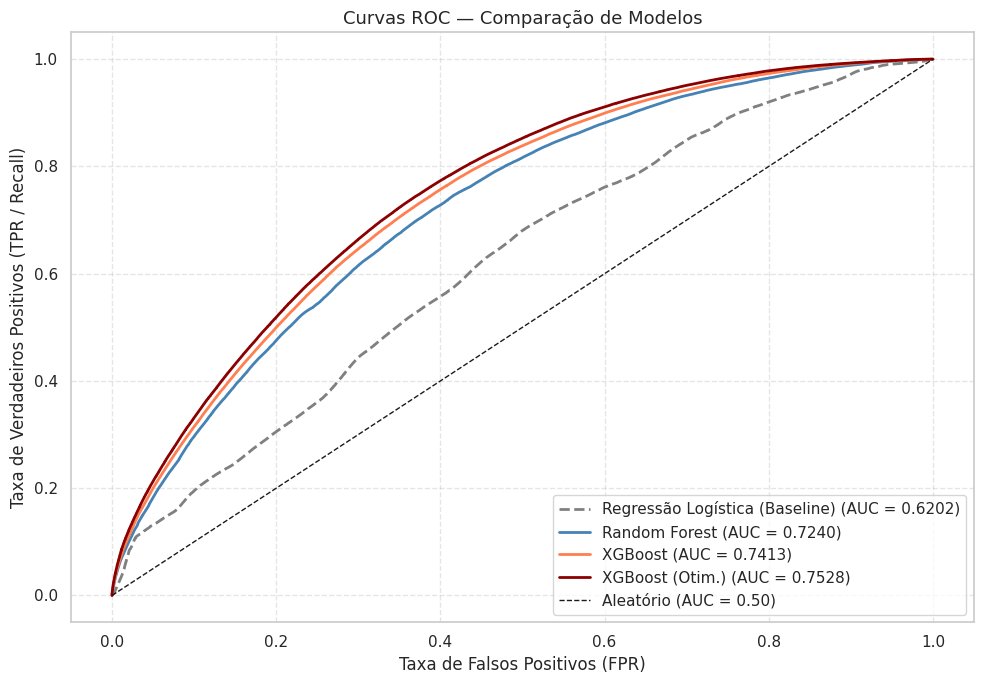

💾 Guardado: /kaggle/working/figures/curvas_roc_comparacao.png


In [30]:
# ── Curvas ROC — todos os modelos ────────────────────────────
plt.figure(figsize=(10, 7))

modelos_roc = [
    (baseline,           'Regressão Logística (Baseline)', X_test_scaled, 'grey',     '--'),
    (rf,                 'Random Forest',                   X_test,        'steelblue', '-'),
    (melhor_candidato,   melhor_candidato_nome,             X_test,        'coral',     '-'),
    (modelo_otimizado,   f'{melhor_candidato_nome} (Otim.)',X_test,        'darkred',   '-'),
]

for modelo_r, nome_r, X_r, cor, ls in modelos_roc:
    y_proba_r = modelo_r.predict_proba(X_r)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba_r)
    auc_r = roc_auc_score(y_test, y_proba_r)
    plt.plot(fpr, tpr, linestyle=ls, color=cor, lw=2,
             label=f'{nome_r} (AUC = {auc_r:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Aleatório (AUC = 0.50)')
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR / Recall)')
plt.title('Curvas ROC — Comparação de Modelos', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
fig_path = '/kaggle/working/figures/curvas_roc_comparacao.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'💾 Guardado: {fig_path}')

### Sumário do Estado do Milestone 3 — até Aula 19

| Aula | Tarefa | Estado |
|------|--------|--------|
| 15 | Divisão estratificada 80/20 com `stratify=y` | Feito |
| 15 | Definição e fundamentação das métricas (AUC-ROC, F1) | Feito |
| 15 | Ponto C — Isolamento do teste, justificação do StandardScaler | Feito |
| 16 | Regressão Logística (Baseline) com `class_weight='balanced'` | Feito |
| 16 | Registo de métricas do baseline | Feito |
| 17 | Random Forest (n_estimators=100, max_depth=10) | Feito |
| 17 | XGBoost/GradientBoosting com `scale_pos_weight` | Feito |
| 17 | Tabela comparativa Treino vs. Teste (todos os modelos) | Feito|
| 18 | Curvas de aprendizagem (3 modelos, diagnóstico automático) | Feito |
| 18 | Exportação de figuras para `reports/figures/` | Feito |
| 19 | RandomizedSearchCV (n_iter=20) com espaço de hiperparâmetros | Feito |
| 19 | StratifiedKFold 5-Fold Cross-Validation (média e std) | Feito |
| 19 | Comparação modelo base vs. otimizado | Feito |
| 19 | Feature Importance + Curvas ROC comparativas | Feito |

In [31]:
# ── Guardar dataset processado final ─────────────────────────
output_path = '/kaggle/working/train_processed.csv'
df_proc.to_csv(output_path, index=False)
print(f' Dataset processado guardado em: {output_path}')
print(f'   {df_proc.shape[0]:,} registos × {df_proc.shape[1]} colunas')

# ── Listagem de figuras exportadas ───────────────────────────
import glob
figuras = glob.glob('/kaggle/working/figures/*.png')
print(f'\n Figuras exportadas para reports/figures/ ({len(figuras)} ficheiros):')
for f in sorted(figuras):
    print(f'   {os.path.basename(f)}')

print('\n Pipeline completo — Milestone 3 (Aulas 15–19) concluído.')

 Dataset processado guardado em: /kaggle/working/train_processed.csv
   5,000,000 registos × 21 colunas

 Figuras exportadas para reports/figures/ (6 ficheiros):
   cross_validation_xgboost.png
   curvas_roc_comparacao.png
   feature_importance_xgboost.png
   learning_curve_random_forest.png
   learning_curve_regressão_logística_baseline.png
   learning_curve_xgboost.png

 Pipeline completo — Milestone 3 (Aulas 15–19) concluído.


MATRIZ DE CONFUSÃO — MODELO FINAL
  Verdadeiros Negativos (VN):  580,607  (58.1%)
  Falsos Positivos      (FP):  249,674  (25.0%)
  Falsos Negativos      (FN):   56,841  (5.7%)
  Verdadeiros Positivos (VP):  112,878  (11.3%)

  Precisão : 0.3113  — dos previstos como clique, quantos clicaram de facto
  Recall   : 0.6651  — dos cliques reais, quantos foram detetados
  Taxa FP  : 0.3007  — anúncios exibidos a utilizadores desinteressados
  Taxa FN  : 0.3349  — oportunidades de receita perdidas


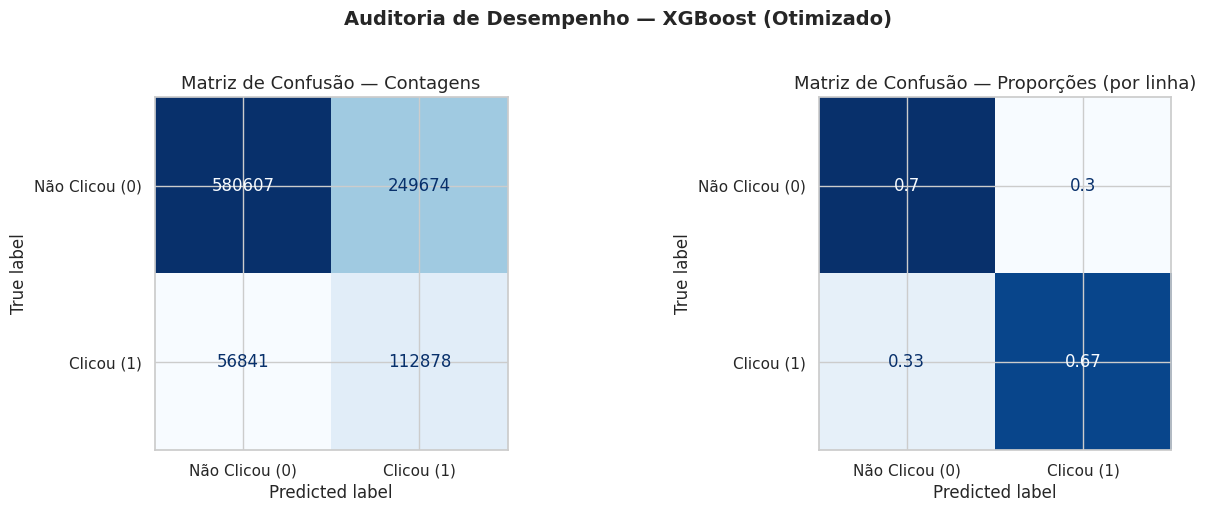


💾 Guardado: /kaggle/working/figures/confusion_matrix_modelo_final.png


In [32]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import os

os.makedirs('/kaggle/working/figures', exist_ok=True)

# ── Previsões do modelo final ─────────────────────────────────
y_pred_final   = modelo_otimizado.predict(X_test)
y_proba_final  = modelo_otimizado.predict_proba(X_test)[:, 1]

# ── Calcular Matriz de Confusão ───────────────────────────────
cm = confusion_matrix(y_test, y_pred_final)
tn, fp, fn, tp = cm.ravel()

total = tn + fp + fn + tp
print('=' * 55)
print('MATRIZ DE CONFUSÃO — MODELO FINAL')
print('=' * 55)
print(f'  Verdadeiros Negativos (VN): {tn:>8,}  ({tn/total*100:.1f}%)')
print(f'  Falsos Positivos      (FP): {fp:>8,}  ({fp/total*100:.1f}%)')
print(f'  Falsos Negativos      (FN): {fn:>8,}  ({fn/total*100:.1f}%)')
print(f'  Verdadeiros Positivos (VP): {tp:>8,}  ({tp/total*100:.1f}%)')
print(f'\n  Precisão : {tp/(tp+fp):.4f}  — dos previstos como clique, quantos clicaram de facto')
print(f'  Recall   : {tp/(tp+fn):.4f}  — dos cliques reais, quantos foram detetados')
print(f'  Taxa FP  : {fp/(fp+tn):.4f}  — anúncios exibidos a utilizadores desinteressados')
print(f'  Taxa FN  : {fn/(fn+tp):.4f}  — oportunidades de receita perdidas')

# ── Visualização ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Contagens absolutas
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Clicou (0)', 'Clicou (1)'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de Confusão — Contagens', fontsize=13)

# Proporções (normalizada por linha)
cm_norm = confusion_matrix(y_test, y_pred_final, normalize='true')
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=['Não Clicou (0)', 'Clicou (1)'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title('Matriz de Confusão — Proporções (por linha)', fontsize=13)

plt.suptitle(f'Auditoria de Desempenho — {melhor_final_nome}', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()

fig_path = '/kaggle/working/figures/confusion_matrix_modelo_final.png'
plt.savefig(fig_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'\n💾 Guardado: {fig_path}')

### Identificação de Padrões de Erro

O modelo tende a errar de forma sistemática em determinados subgrupos de dados.
A análise seguinte isola as instâncias mal classificadas e compara as suas características médias
com as instâncias corretamente classificadas, permitindo identificar onde e porquê o modelo falha.

In [33]:
import pandas as pd

# ── Construir DataFrame de diagnóstico ───────────────────────
df_teste = X_test.copy()
df_teste['click_real']    = y_test.values
df_teste['click_previsto'] = y_pred_final
df_teste['probabilidade']  = y_proba_final

# Classificar cada instância
df_teste['resultado'] = 'VN'  # default
df_teste.loc[(df_teste['click_real'] == 1) & (df_teste['click_previsto'] == 1), 'resultado'] = 'VP'
df_teste.loc[(df_teste['click_real'] == 0) & (df_teste['click_previsto'] == 1), 'resultado'] = 'FP'
df_teste.loc[(df_teste['click_real'] == 1) & (df_teste['click_previsto'] == 0), 'resultado'] = 'FN'

print(f'Distribuição dos resultados de classificação:')
print(df_teste['resultado'].value_counts().to_string())

# ── Perfil médio por tipo de resultado ───────────────────────
cols_analise = ['banner_pos', 'device_type', 'device_conn_type', 'C1', 'C14', 'C15', 'C16']
cols_analise = [c for c in cols_analise if c in df_teste.columns]

perfil = df_teste.groupby('resultado')[cols_analise].mean().round(3)
print('\n' + '='*65)
print('PERFIL MÉDIO POR TIPO DE CLASSIFICAÇÃO')
print('='*65)
display(perfil)

# ── Comparação FN vs VP (cliques: detetados vs. falhados) ────
fn_df = df_teste[df_teste['resultado'] == 'FN']
vp_df = df_teste[df_teste['resultado'] == 'VP']

print('\n' + '='*65)
print('COMPARAÇÃO: Falsos Negativos (FN) vs. Verdadeiros Positivos (VP)')
print('Cliques reais — os que o modelo FALHOU vs. os que ACERTOU')
print('='*65)

comparacao = pd.DataFrame({
    'FN (cliques falhados)': fn_df[cols_analise].mean().round(3),
    'VP (cliques acertados)': vp_df[cols_analise].mean().round(3),
    'Diferença': (fn_df[cols_analise].mean() - vp_df[cols_analise].mean()).round(3)
})
display(comparacao)

# ── Probabilidades médias nos erros ──────────────────────────
print(f'\nProbabilidade média de clique nos FN: {fn_df["probabilidade"].mean():.4f}')
print(f'Probabilidade média de clique nos VP: {vp_df["probabilidade"].mean():.4f}')
print(f'\n → Os FN têm probabilidade baixa atribuída, mas eram cliques reais.')
print(f'   Isso sugere que o modelo não capturou bem o padrão destes utilizadores.')

Distribuição dos resultados de classificação:
resultado
VN    580607
FP    249674
VP    112878
FN     56841

PERFIL MÉDIO POR TIPO DE CLASSIFICAÇÃO


,banner_pos,device_type,device_conn_type,C1,C14,C15,C16
resultado,,,,,,,
FN,0.261,1.000,0.245,1004.920,18482.705,319.370,51.880
FP,0.340,0.952,0.131,1004.836,17933.450,317.738,66.909
VN,0.257,1.056,0.462,1005.050,19429.446,319.786,53.110
VP,0.347,0.956,0.133,1004.856,18028.968,316.352,84.308



COMPARAÇÃO: Falsos Negativos (FN) vs. Verdadeiros Positivos (VP)
Cliques reais — os que o modelo FALHOU vs. os que ACERTOU


,FN (cliques falhados),VP (cliques acertados),Diferença
banner_pos,0.261,0.347,-0.086
device_type,1.000,0.956,0.044
device_conn_type,0.245,0.133,0.112
C1,1004.920,1004.856,0.064
C14,18482.705,18028.968,453.736
C15,319.370,316.352,3.019
C16,51.880,84.308,-32.428



Probabilidade média de clique nos FN: 0.3466
Probabilidade média de clique nos VP: 0.6563

 → Os FN têm probabilidade baixa atribuída, mas eram cliques reais.
   Isso sugere que o modelo não capturou bem o padrão destes utilizadores.


In [34]:
# ── Listar todas as figuras exportadas ───────────────────────
figuras = sorted(glob.glob('/kaggle/working/figures/*.png'))

print('=' * 60)
print('FIGURAS EXPORTADAS PARA reports/figures/')
print('=' * 60)
for f in figuras:
    print(f'  📊 {os.path.basename(f)}')

FIGURAS EXPORTADAS PARA reports/figures/
  📊 confusion_matrix_modelo_final.png
  📊 cross_validation_xgboost.png
  📊 curvas_roc_comparacao.png
  📊 feature_importance_xgboost.png
  📊 learning_curve_random_forest.png
  📊 learning_curve_regressão_logística_baseline.png
  📊 learning_curve_xgboost.png
